# Model report -- granular varieties, comparative advantage at the attraction-area level

The FIT of the structural model to its targets: the moment table, the sourcing-share and
downstream-sales fit, the extensive margin and the zero-supplier share with their standard
errors, the count curve, the Jacobian and what it says about identification, the moment
covariance matrices, and the untargeted distance elasticity of spatial comovement.

The companion notebook, `tests_counterfactuals.ipynb`, interrogates the same model one
test at a time and runs the counterfactuals.

Every function called here lives in `utils.py` or `report_lib.py`. Each section runs on
its own after the imports and the Constants cell.


## Setup

In [38]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow scipy



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [39]:
# The libraries. Every function this notebook calls lives in one of them, so a section
# is edited in a file rather than in a 1,400-line cell, and the gates under `test/`
# import the same code instead of slicing it out of the notebook's JSON.
#
#   utils.py       the loader, `theta+`, the Ricardian geometry, and THE ECONOMY
#   report_lib.py  the moment fit, the count curve, the Jacobian, identification, and
#                  the untargeted distance elasticity
#
# Reload after editing one of them: `import importlib; importlib.reload(utils)` --
# or restart the kernel, which is safer once several modules have changed.
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import utils
import report_lib
from utils import *
from report_lib import *


In [40]:
# Set the width of your LaTeX document in points

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
cmap = plt.get_cmap('viridis')

toulouse_color = (132/255, 46/255, 27/255)
document_width_pt = 511.
font_size = 20  # Adjust according to your preference
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size+2,
    "xtick.labelsize": font_size-3,
    "ytick.labelsize": font_size-3,
    "legend.fontsize": font_size-3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
})


## Constants

In [41]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]

# The run tree, and WHICH PARTS of it to read. This notebook reports the fit, so it
# reads the moment vector, the inference artefacts, the Jacobian and the count curve.
# It does NOT read `suppliers.parquet`: the firm-level panel behind the untargeted
# moment is simulated from `theta+` like every other economy (see the section below).
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso",
                  parts=("core", "counts", "moments", "inference", "jacobian",
                         "geography"))

# Highest K kept anywhere in the count-curve reporting: the panels, the empirical
# increments read out of G_K.csv, and the bootstrap variances read out of G_K_var.csv
# are ALL truncated here. K = 0 is the targeted moment (block 6); everything above it
# is a free check on the SHAPE of the supplier-count distribution (gate V8).
COUNT_CURVE_K_MAX = 3
COUNT_CURVE_K = tuple(range(COUNT_CURVE_K_MAX + 1))

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the
# exposure, so its delta/gamma is a compressed reading of an elasticity and the
# compression depends on this number.
EMPIRICAL_MEAN_LOG_D = 5.8

for _m in (utils, report_lib):
    for _k in ("COUNT_CURVE_K_MAX", "EMPIRICAL_MEAN_LOG_D"):
        if hasattr(_m, _k):
            setattr(_m, _k, globals()[_k])

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)


## Loading

`utils.load_granular_data(industry, mu, parts=...)` rebuilds, on the Python side, the
layout `load_parameters.jl` builds under `--granular=true --ca_level=aa`: the FULL moment
vector

    [labor(1) | industry(S) | pi_r(R_d) | reg_coef(N_REG) | gamma_aa(S x n_AA, s-major)
     | Gbar_s(0)(S)]

and MOMENT_MASK exactly as the estimator builds it, plus both Jacobian axes and the
inference artefacts. `parts` says which blocks to read; this notebook asks for everything
but `firm`, since the firm-level panel behind the untargeted moment is simulated from
`theta+` rather than read from `suppliers.parquet`.

`mu` selects the estimate: `mu=1` reads `step1/` with standard errors from
`step2/inference/`, `mu=2` reads `step3/` for both.


# Reporting

## Moment table

Empirical against simulated for the two blocks that read naturally as a table: the
aggregate labor share (Panel A) and the sectoral industry shares (Panel B), both
industries side by side, with `---` where a sector is absent from an industry's sample.

The distance coefficients and the zero-supplier shares are *not* table panels here. They
are few enough to plot, and they are the two blocks where the sampling uncertainty
matters for reading the fit, so they get their own figures with standard errors below.


In [42]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
Combined table saved to: ../reporting_combined/moments_comparison_combined_mu2.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-for

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


## Fit: sourcing shares and downstream sales

Simulated against empirical, on the 45-degree line. Bubble area is proportional to the
empirical value, so a visually large miss on a small moment is seen for what it is.

For the sourcing shares $\gamma_{s,a}$ the figure reproduces the first panel of the Julia
dashboard. Each sector's **reference area** is dropped from the criterion, so its
simulated value is not fitted directly; it is reconstructed from the within-sector
adding-up constraint

$$\gamma_{\text{ref},s} \;=\; c_s - \sum_{a \neq \text{ref}} \gamma_{s,a},$$

and drawn in a separate colour. The fit statistics annotated on the panel (a weighted
regression through the origin) use the non-reference points only — the reconstructed
ones are an identity, not an independent observation.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


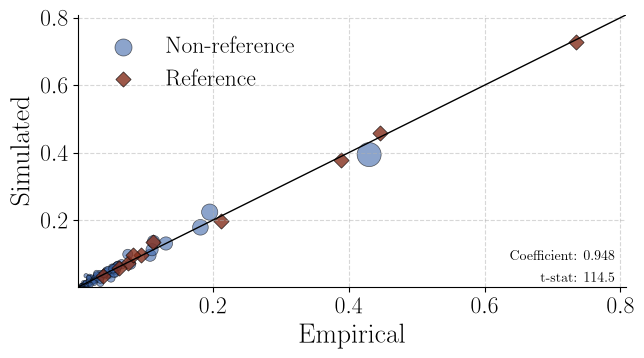

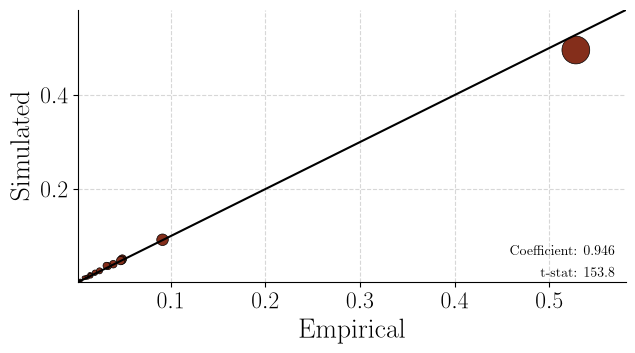

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


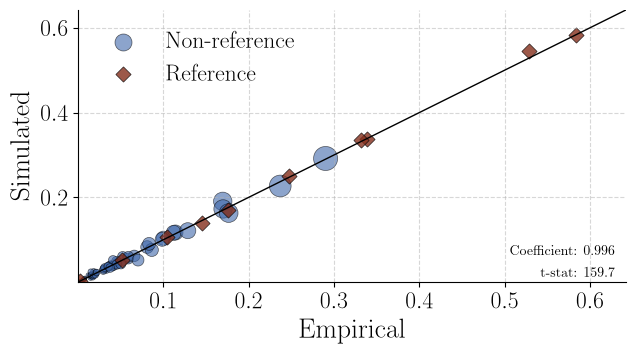

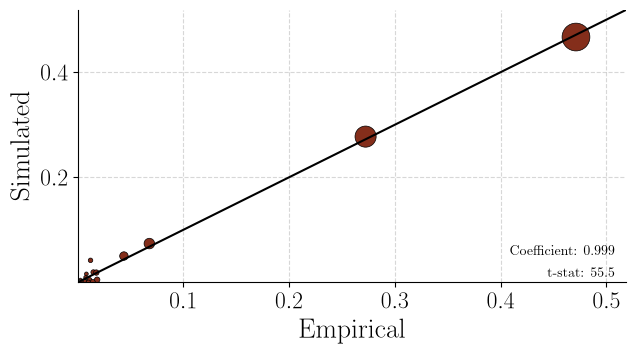

In [43]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()


## Fit with standard errors: extensive margin and zero-supplier share

The two blocks where the comparison is only meaningful against sampling uncertainty: the
cloglog distance-bin coefficients (block 4) and the zero-supplier shares $\bar G_s(0)$
(block 6). Each tick carries the empirical value on the left and the simulated one on the
right, both with 95% bars. **Two different objects, deliberately:**

* **Empirical bars** — $\sqrt{\mathrm{diag}(\Sigma_{data})}$, the bootstrap sampling
  standard error of the moment *in the data*. How precisely the target is measured.
* **Simulated bars** — `se_moments_fitted.npy`, the standard error of the *fitted*
  moment, $\sqrt{\mathrm{diag}(G\,V\,G')}$, i.e. the estimation uncertainty of the
  parameters carried through to the moment they generate.

Under the profiled estimator (`--profile_T=true`, what these runs use) $V$ is the
**sandwich** covariance of $\hat\alpha$ and $G = \partial m / \partial \alpha$ is the
*profiled* Jacobian — $\alpha$ moved with $T$ following through the Sinkhorn inversion.
So the simulated bar is the delta-method propagation of $\hat\alpha$'s sandwich standard
error onto that moment, not an efficient standard error built from the free-parameter
Jacobian: under profiling $T$ is not a free parameter, it is a function of $\alpha$ and of
the sourcing-share targets, and the reported bar takes that dependence into account.
Two consequences worth keeping in mind when reading the figure: the bar does *not*
include the data noise of the $\gamma$ targets that $T$ is inverted from (that channel is
reported separately, in Julia's `inference_delta.txt`), and $\bar G_s(0)$'s bar does not
include the uncertainty of $\hat N_s$, which is calibrated on that very moment.

Both numbers come out of the Julia inference step; nothing is re-estimated here.

Each sector of the $\bar G_s(0)$ panel is annotated with its profiled variety count
$\hat N_s$, starred when it sits on a bound: a sector clamped at a bound cannot close its
own count residual through $\hat N_s$, so a visible miss there is expected rather than a
fit failure.

**Where the same numbers appear on the Julia side, and why they must agree.**
$\bar G_s(0)$ is written down in four places, and the panel shows two of them: the red
marker is `G_K.csv` at $K = 0$ (block 6 of the empirical moment vector, printed as
`G0_emp` in a stage `report.txt`), the blue one is block 6 of
`<step>/best_simulated_moments.npy`, which `run_reporting` evaluates at the **last stage
folder's** `best_params.npy` on `U_DRAWS`. The other two are `G0_target` and `G0_fit` in
`<step>/granular_diagnostics.npz` (and its `.txt` twin), which `report_granular` computes
at the $\hat\theta$ that step saved. The two $\theta$ are the same vector —
`run_optimization` returns its final sub-stage's parameters and writes that same vector
into the last stage folder — and $\bar G_s(0)$ is a closed form in the win counts, so it
carries no simulation noise of its own: the two pairs must agree to the solver tolerance.

**The rest of the curve, $\bar G_s(1), \bar G_s(2), \bar G_s(3)$.** Only $K = 0$ is
targeted, and it is targeted *tightly*: $\hat N_s$ is the integer that solves
$\bar G_s(0) = \hat G_s$, so a good fit in that panel is close to mechanical. Nothing in
the criterion asks the model to reproduce the **shape** of the supplier-count
distribution, which makes $K \geq 1$ a free check — gate V8 of
`documentation/granular_validation.md` — on whether one variety count per sector is
enough structure to generate the observed spread of $K_{ls}$, or whether the model
concentrates suppliers into too few cells (the simulated curve then climbs too fast) or
scatters them over too many (too slow).

Neither side of it is on disk. The empirical curve is the rest of `G_K.csv`, which
`load_parameters.jl` reads only at $K = 0$; the simulated curve Julia never evaluates at
all, since the moment vector stops there. `count_curve` rebuilds it from the two
diagnostics that determine it, $\hat q_{ls}$ and $\hat N_s$: a cell hosts a supplier for
each variety it wins somewhere, so $K_{ls} \sim \mathrm{Bin}(\hat N_s, \hat q_{ls})$ and
$\bar G_s(K) = \mathrm{mean}_l \Pr(K_{ls} \leq K)$. It is estimated under the same
unbiased convention `gbar_cell` uses — take the $\hat N_s$ varieties to be that many of
the $m$ simulated draws sampled without replacement, so the win count among them is
hypergeometric and $\mathbb{E}[C(k,j)C(m-k,\hat N_s-j)/C(m,\hat N_s)]$ is the binomial
pmf exactly — which at $K = 0$ collapses to `gbar_cell` itself. That is what ties the
untargeted panels to the targeted one, and it is checked rather than asserted: the
rebuilt $K = 0$ column must reproduce block 6 of the moment vector, or the function falls
back to the plug-in binomial and says so.

**Standard errors on $K = 0$ only.** $\Sigma_{data}$'s count block is the $S$ rows of
$\bar G_s(0)$; the bootstrap never covered the rest of the curve, so a bar there would be
invented.

They come apart for one reason, and it is a bookkeeping one rather than a modelling one:
`report_granular` writes the npz only when *its* step runs (Step 2 at $\hat\theta_1$,
Step 4 at $\hat\theta_2$), whereas `main.jl`'s post-hoc block rewrites
`best_simulated_moments.npy` on **every** invocation. A run resumed with
`run_step4 = false` therefore leaves the reporting frozen at an older $\theta$ while the
figure follows the newest one. `g0_consistency(data)` puts all four columns side by side
and says which of the two gaps opened; `plot_G0` calls it and warns if either does.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


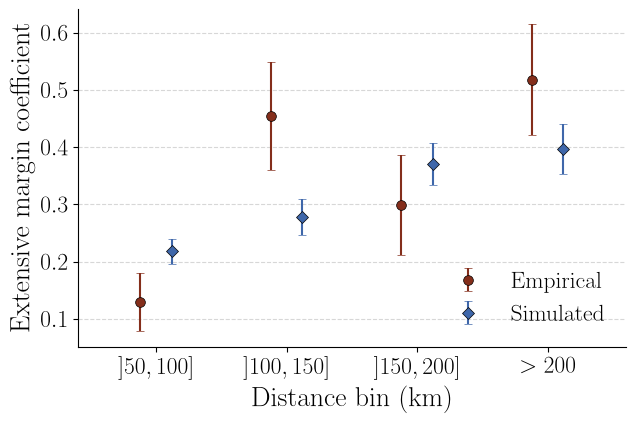

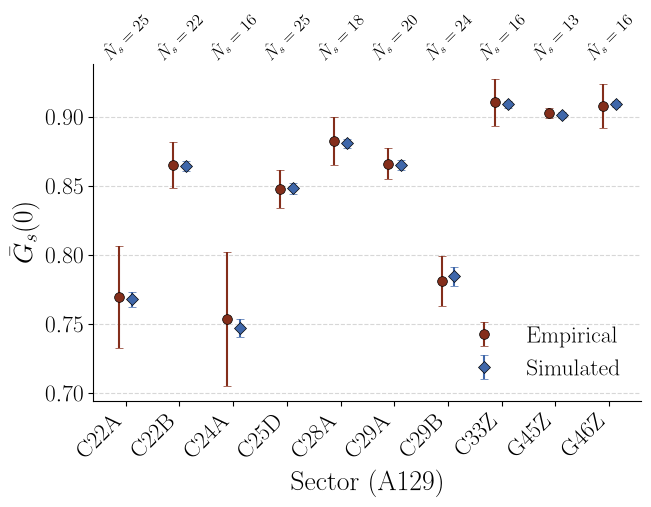

[g0_consistency] auto (mu = 2) OK — reporting_auto_profiled_aa_gran_nlo1_pso: moments step3/best_simulated_moments.npy vs step3/granular_diagnostics.npz; max |gap| target 1.11e-16, fit 0.00e+00


,target (G_K.csv),target (diagnostics),d_target,fit (moment vector),fit (diagnostics),d_fit,N_hat,clamp,residual (fit - target)
A129,,,,,,,,,
C22A,0.769912,0.769912,0.000000e+00,0.767891,0.767891,0.0,25.0,none,-0.002021
C22B,0.865000,0.865000,0.000000e+00,0.864389,0.864389,0.0,22.0,none,-0.000611
C24A,0.753623,0.753623,0.000000e+00,0.747202,0.747202,0.0,16.0,none,-0.006421
C25D,0.847826,0.847826,0.000000e+00,0.848474,0.848474,0.0,25.0,none,0.000648
C28A,0.882682,0.882682,0.000000e+00,0.880856,0.880856,0.0,18.0,none,-0.001825
C29A,0.866279,0.866279,0.000000e+00,0.864966,0.864966,0.0,20.0,none,-0.001313
C29B,0.781250,0.781250,0.000000e+00,0.784553,0.784553,0.0,24.0,none,0.003303
C33Z,0.910448,0.910448,0.000000e+00,0.909296,0.909296,0.0,16.0,none,-0.001151
G45Z,0.902778,0.902778,0.000000e+00,0.901209,0.901209,0.0,13.0,none,-0.001569


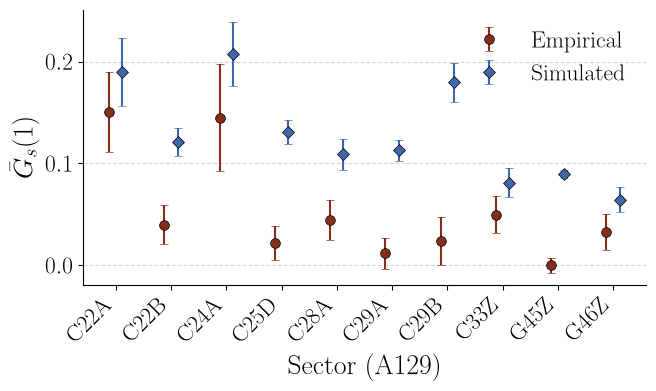

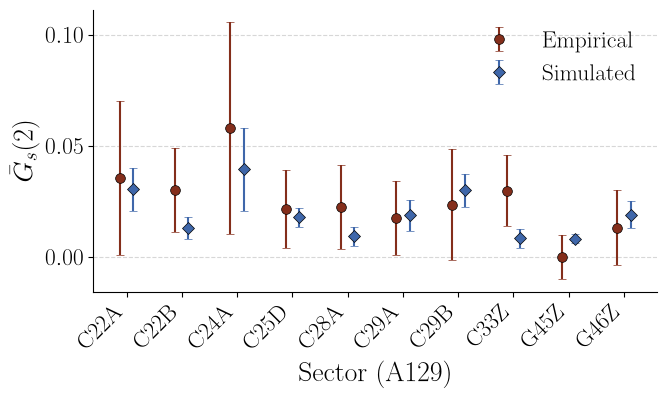

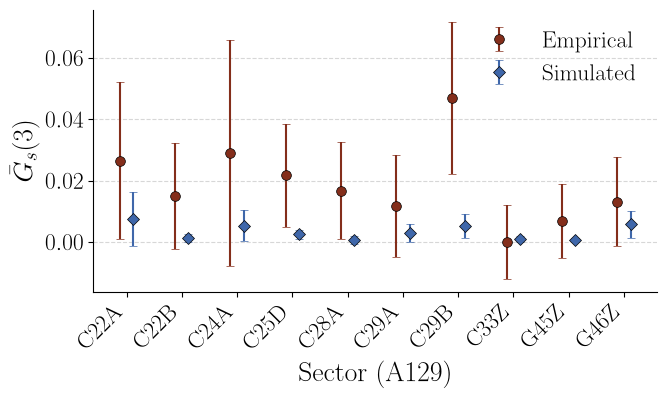

empirical                               simulated                      \
K            0         1         2         3         0         1         2   
A129                                                                         
C22A  0.769912  0.150442  0.035398  0.026549  0.767891  0.189910  0.030454   
C22B  0.865000  0.040000  0.030000  0.015000  0.864389  0.121243  0.013134   
C24A  0.753623  0.144928  0.057971  0.028986  0.747202  0.207460  0.039424   
C25D  0.847826  0.021739  0.021739  0.021739  0.848474  0.130566  0.017928   
C28A  0.882682  0.044693  0.022346  0.016760  0.880856  0.109047  0.009324   
C29A  0.866279  0.011628  0.017442  0.011628  0.864966  0.112712  0.018762   
C29B  0.781250  0.023438  0.023438  0.046875  0.784553  0.179447  0.029926   
C33Z  0.910448  0.049751  0.029851  0.000000  0.909296  0.081190  0.008486   
G45Z  0.902778  0.000000  0.000000  0.006944  0.901209  0.089740  0.008193   
G46Z  0.907895  0.032895  0.013158  0.013158  0.909313  0.064491  0.019003   

               se_empirical            ... N_hat     clamped                \
K            3            0         1  ...     2   3       0      1      2   
A129                                   ...                                   
C22A  0.007430     0.018883  0.020130  ...    25  25   False  False  False   
C22B  0.001154     0.008435  0.009897  ...    22  22   False  False  False   
C24A  0.005320     0.024620  0.026772  ...    16  16   False  False  False   
C25D  0.002474     0.006926  0.008605  ...    25  25   False  False  False   
C28A  0.000716     0.008899  0.010033  ...    18  18   False  False  False   
C29A  0.003032     0.005852  0.007677  ...    20  20   False  False  False   
C29B  0.005180     0.009249  0.012003  ...    24  24   False  False  False   
C33Z  0.000942     0.008672  0.009374  ...    16  16   False  False  False   
G45Z  0.000795     0.001942  0.003685  ...    13  13   False  False  False   
G46Z  0.005765     0.008081  0.009151  ...    16  16   False  False  False   

            targeted                       
K         3        0      1      2      3  
A129                                       
C22A  False     True  False  False  False  
C22B  False     True  False  False  False  
C24A  False     True  False  False  False  
C25D  False     True  False  False  False  
C28A  False     True  False  False  False  
C29A  False     True  False  False  False  
C29B  False     True  False  False  False  
C33Z  False     True  False  False  False  
G45Z  False     True  False  False  False  
G46Z  False     True  False  False  False  

[10 rows x 32 columns]

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


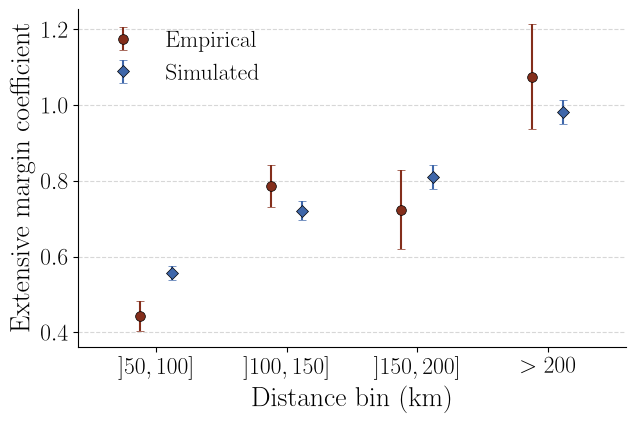

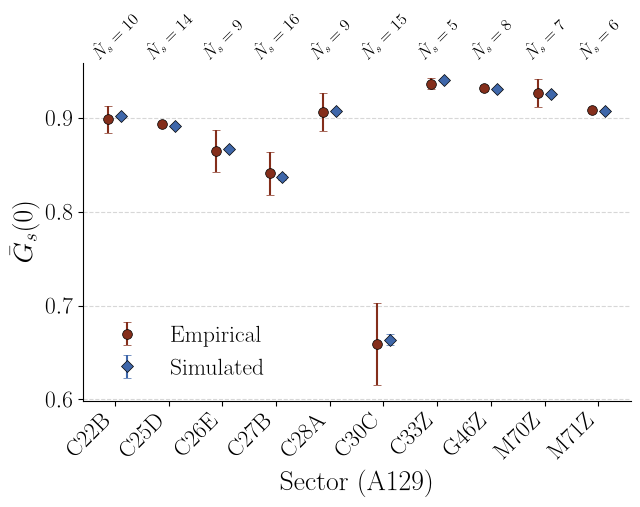

[g0_consistency] aero (mu = 2) OK — reporting_aero_profiled_aa_gran_nlo1_pso: moments step3/best_simulated_moments.npy vs step3/granular_diagnostics.npz; max |gap| target 0.00e+00, fit 0.00e+00


,target (G_K.csv),target (diagnostics),d_target,fit (moment vector),fit (diagnostics),d_fit,N_hat,clamp,residual (fit - target)
A129,,,,,,,,,
C22B,0.898305,0.898305,0.0,0.901466,0.901466,0.0,10.0,none,0.003161
C25D,0.893519,0.893519,0.0,0.891625,0.891625,0.0,14.0,none,-0.001893
C26E,0.864583,0.864583,0.0,0.867160,0.867160,0.0,9.0,none,0.002577
C27B,0.840764,0.840764,0.0,0.836851,0.836851,0.0,16.0,none,-0.003913
C28A,0.906250,0.906250,0.0,0.907238,0.907238,0.0,9.0,none,0.000988
C30C,0.659091,0.659091,0.0,0.663431,0.663431,0.0,15.0,none,0.004340
C33Z,0.936306,0.936306,0.0,0.940746,0.940746,0.0,5.0,none,0.004440
G46Z,0.931677,0.931677,0.0,0.930469,0.930469,0.0,8.0,none,-0.001208
M70Z,0.926471,0.926471,0.0,0.925149,0.925149,0.0,7.0,none,-0.001321


[count_curve] aero: the supplied G_K_var.csv disagrees with diag(Sigma_data)'s count block at K = 0 by up to 100.0%. They are the SAME object (p_s(0) = G_s(0)), so one of the two bootstraps is not the one the estimator used — most likely the CSV holds the CDF's variance rather than the increment's, which coincide only at K = 0 if the resampling is identical.


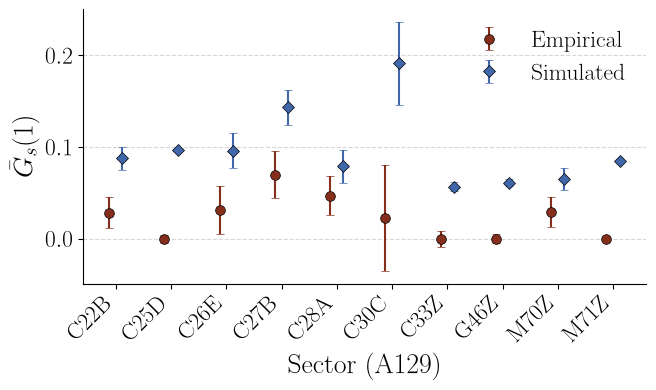

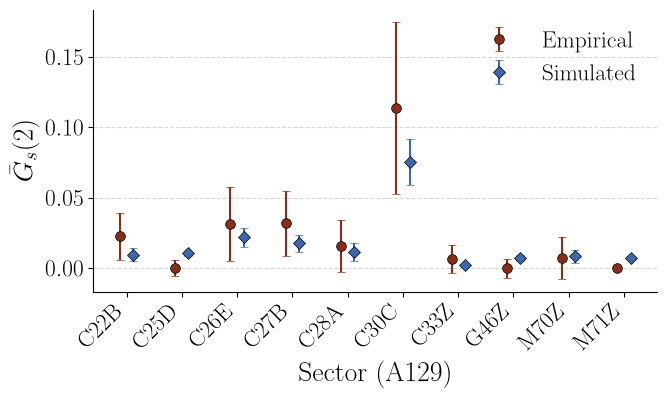

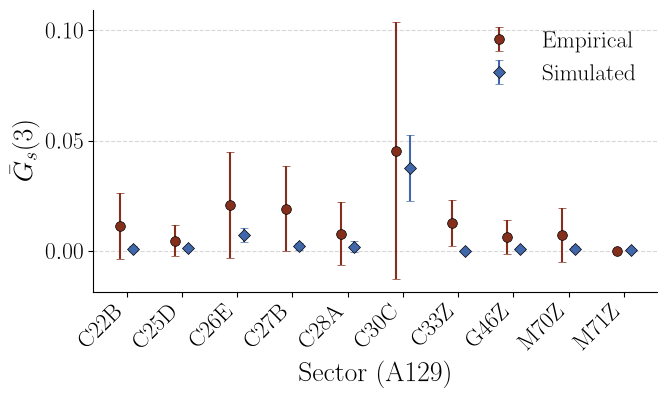

empirical                               simulated                      \
K            0         1         2         3         0         1         2   
A129                                                                         
C22B  0.898305  0.028249  0.022599  0.011299  0.901466  0.087864  0.009507   
C25D  0.893519  0.000000  0.000000  0.004630  0.891625  0.096700  0.010468   
C26E  0.864583  0.031250  0.031250  0.020833  0.867160  0.096275  0.021821   
C27B  0.840764  0.070064  0.031847  0.019108  0.836851  0.143270  0.017548   
C28A  0.906250  0.046875  0.015625  0.007812  0.907238  0.078966  0.011552   
C30C  0.659091  0.022727  0.113636  0.045455  0.663431  0.191363  0.075333   
C33Z  0.936306  0.000000  0.006369  0.012739  0.940746  0.056986  0.002212   
G46Z  0.931677  0.000000  0.000000  0.006211  0.930469  0.061288  0.007106   
M70Z  0.926471  0.029412  0.007353  0.007353  0.925149  0.065159  0.008549   
M71Z  0.908257  0.000000  0.000000  0.000000  0.907757  0.084749  0.007056   

               se_empirical            ... N_hat     clamped                \
K            3            0         1  ...     2   3       0      1      2   
A129                                   ...                                   
C22B  0.001045     0.007500  0.008685  ...    10  10   False  False  False   
C25D  0.001093     0.001148  0.002119  ...    14  14   False  False  False   
C26E  0.007116     0.011308  0.013503  ...     9   9   False  False  False   
C27B  0.002075     0.011554  0.012888  ...    16  16   False  False  False   
C28A  0.001957     0.010121  0.010828  ...     9   9   False  False  False   
C30C  0.037546     0.022455  0.029601  ...    15  15   False  False  False   
C33Z  0.000056     0.002960  0.004458  ...     5   5   False  False  False   
G46Z  0.001019     0.001508  0.002650  ...     8   8   False  False  False   
M70Z  0.001047     0.007664  0.008263  ...     7   7   False  False  False   
M71Z  0.000422     0.000000  0.000000  ...     6   6   False  False  False   

            targeted                       
K         3        0      1      2      3  
A129                                       
C22B  False     True  False  False  False  
C25D  False     True  False  False  False  
C26E  False     True  False  False  False  
C27B  False     True  False  False  False  
C28A  False     True  False  False  False  
C30C  False     True  False  False  False  
C33Z  False     True  False  False  False  
G46Z  False     True  False  False  False  
M70Z  False     True  False  False  False  
M71Z  False     True  False  False  False  

[10 rows x 32 columns]

In [44]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()
    # The figure against Julia's own reporting of the same moment, sector by sector.
    display(g0_consistency(data))
    # ... and the rest of the count curve, which nothing in the criterion targets.
    cc = count_curve(data, K_values=COUNT_CURVE_K)
    # one figure per K, each in its own file; K = 0 is `plot_G0` above, which carries
    # the N_hat annotation, so only the untargeted K >= 1 are drawn here
    plot_count_curve(data, df=cc, K_values=[K for K in COUNT_CURVE_K if K > 0],
                     save_to=f"{out_folder}/emp_sim_count_curve_{industry}_mu{MU}.pdf")
    plt.show()
    display(cc.unstack("K"))


# Jacobian and variance-covariance

## Jacobian — which parameter moves which moment

Rows are the moments the criterion actually uses (the masked vector, six blocks),
columns are the parameters. The parameter axis is
$[\Omega^L \mid \Omega^s \mid A \mid \alpha \mid T \mid N_s]$: the head parameters, the
trade-cost elasticity, the comparative advantages, and — appended on the right — the
**variety counts**.

**Why $N_s$ is in the picture.** $T$ and $N_s$ are both *calibrated* rather than
searched over: $T$ is the Sinkhorn image that reproduces the observed sourcing shares at
a given $\alpha$, $N_s$ is the solution of $\bar G_s(n) = \hat G_s$ found by integer
bisection. $T$ appeared in the Jacobian only because it happens to be a coordinate of the
parameter vector and $N_s$ is not — a bookkeeping accident, not a statement about the
model. The Julia side now appends $\partial m/\partial N_s$ to the saved Jacobian, so the
matrix covers every parameter the model has. Two conventions for reading those columns:

* the derivative is a unit **first difference** $m(N_s+1) - m(N_s)$. $N_s$ is an integer,
  so one variety *is* the step and there is no step size to choose;
* the zeros outside block 6 are **structural**, not numerical. The two evaluations share
  the same productivity draws, so any moment with no $N_s$ term differences to exactly
  `0.0`, and Julia asserts it (the extensive margin is $N_s$-free by Proposition 1, the
  win probabilities by Lemma 2). An exact zero in an $N_s$ column is the model saying the
  channel does not exist, not a small number that fell below a threshold.

**What is plotted is the elasticity** $\varepsilon_{jk} = \partial \log m_j / \partial
\log \theta_k$ (for $N_s$, $\hat N_s \cdot \partial m_j/\partial N_s / m_j$). The raw
$\partial m/\partial\theta$ mixes units across blocks and cannot share one colour scale.

**The noise-to-signal triptych.** These derivatives are finite differences of *simulated*
moments, so each entry is itself an estimate: `compute_jacobian` averages over $K$
independent draw sets and reports the across-replication standard deviation
$\sigma_{jk}$. An entry is readable only if $\sigma_{jk}/|\varepsilon_{jk}|$ is small —
a large elasticity with a larger standard deviation is not evidence of a channel, and a
zero there means "not measured", not "not there". So each elasticity figure comes in
three panels:

1. the elasticity Jacobian as it is;
2. the noise-to-signal ratio $\sigma/|\varepsilon|$ alone, with the cells that fail the
   criterion marked — which parts of panel 1 are readable at all;
3. the elasticity Jacobian with those cells blanked to white — what survives.

A cell fails when $\sigma/|\varepsilon| \geq$ `NOISE_MAX` (default 0.5: the Monte-Carlo
standard deviation is at least half the elasticity itself). Entries that are *exactly*
zero are treated as readable, since a structural zero carries no simulation noise —
distinguishing them from unmeasured entries is the whole point of the panel.

**Under `profile_T` this is the FREE-parameter Jacobian**, saved for diagnostics: it
answers "what would move if $T$ were free". The inference itself runs on the $\alpha$-only
profiled Jacobian, where $T$ follows $\alpha$ through the Sinkhorn inversion.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
auto: S=10  n_AA=22  N_REG=4  10 variety-count columns in the Jacobian


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


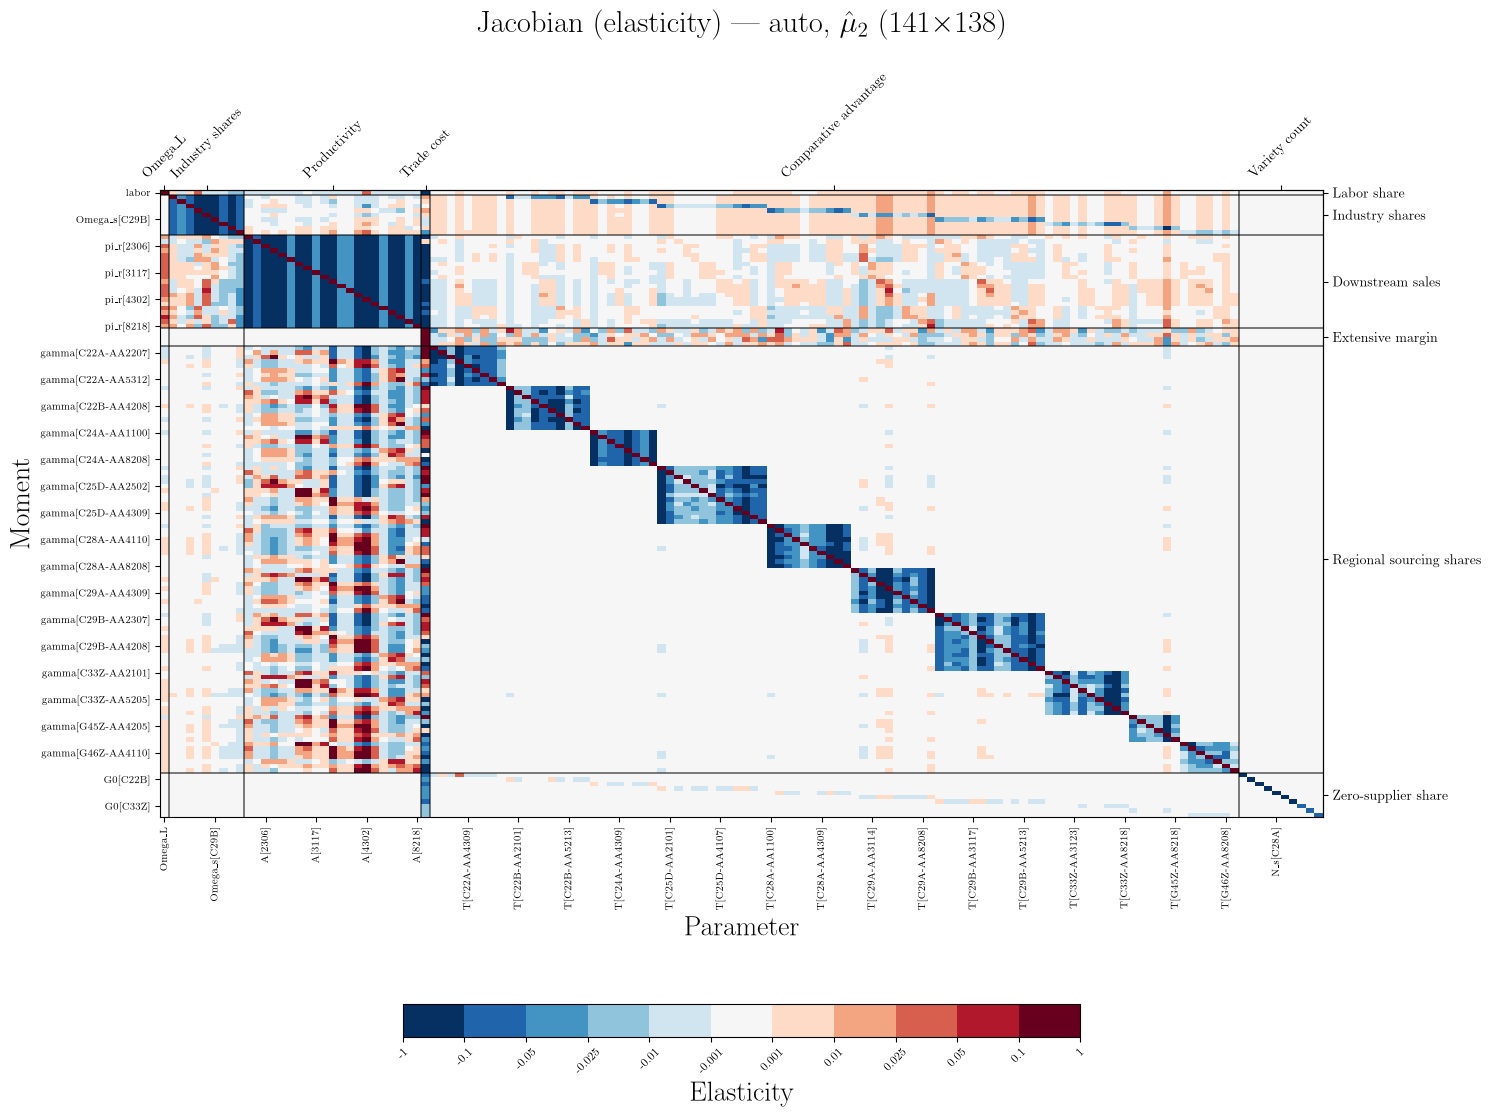

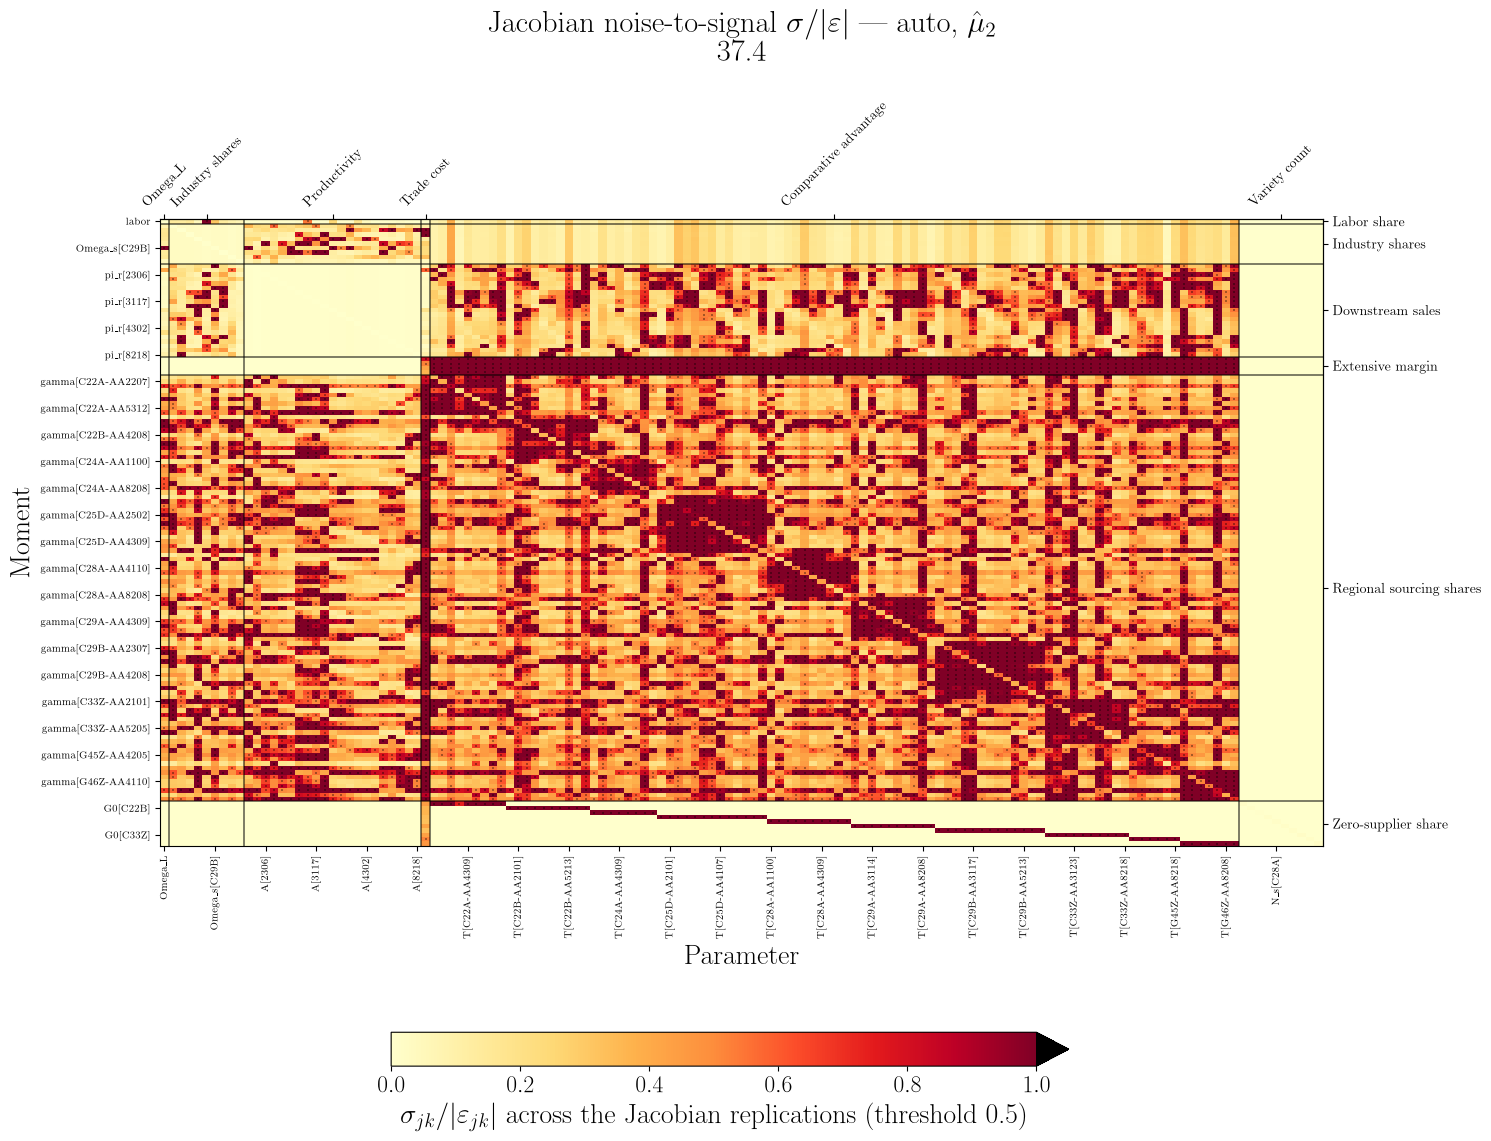

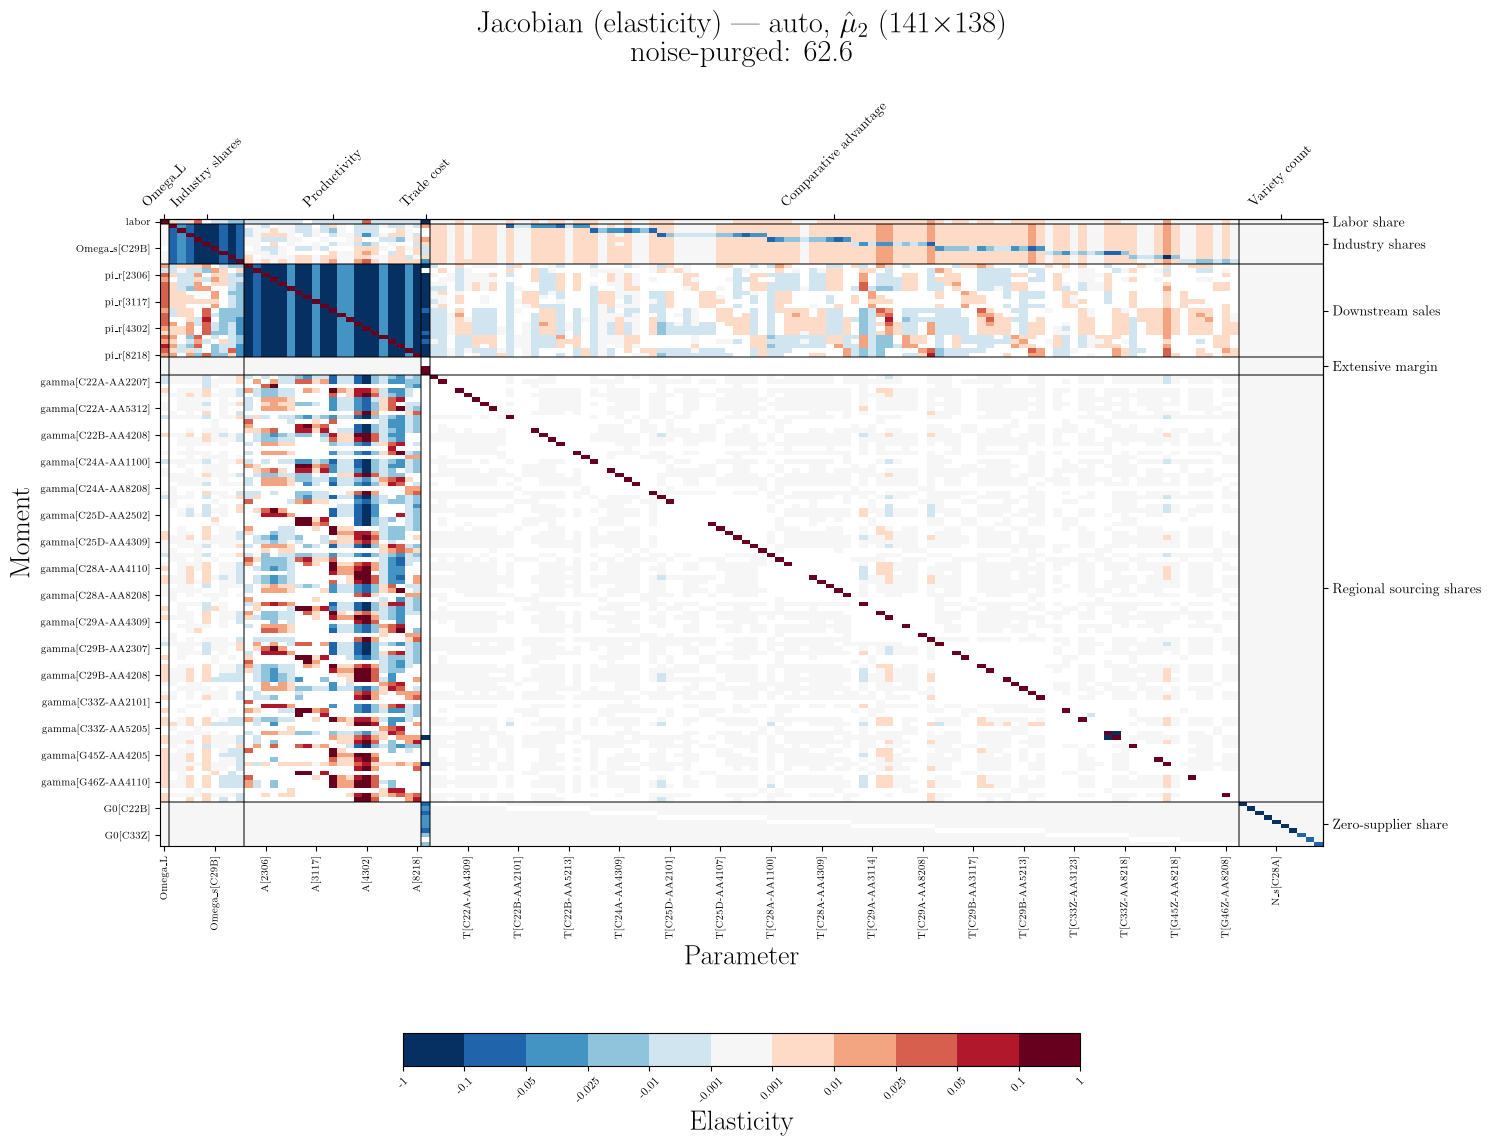

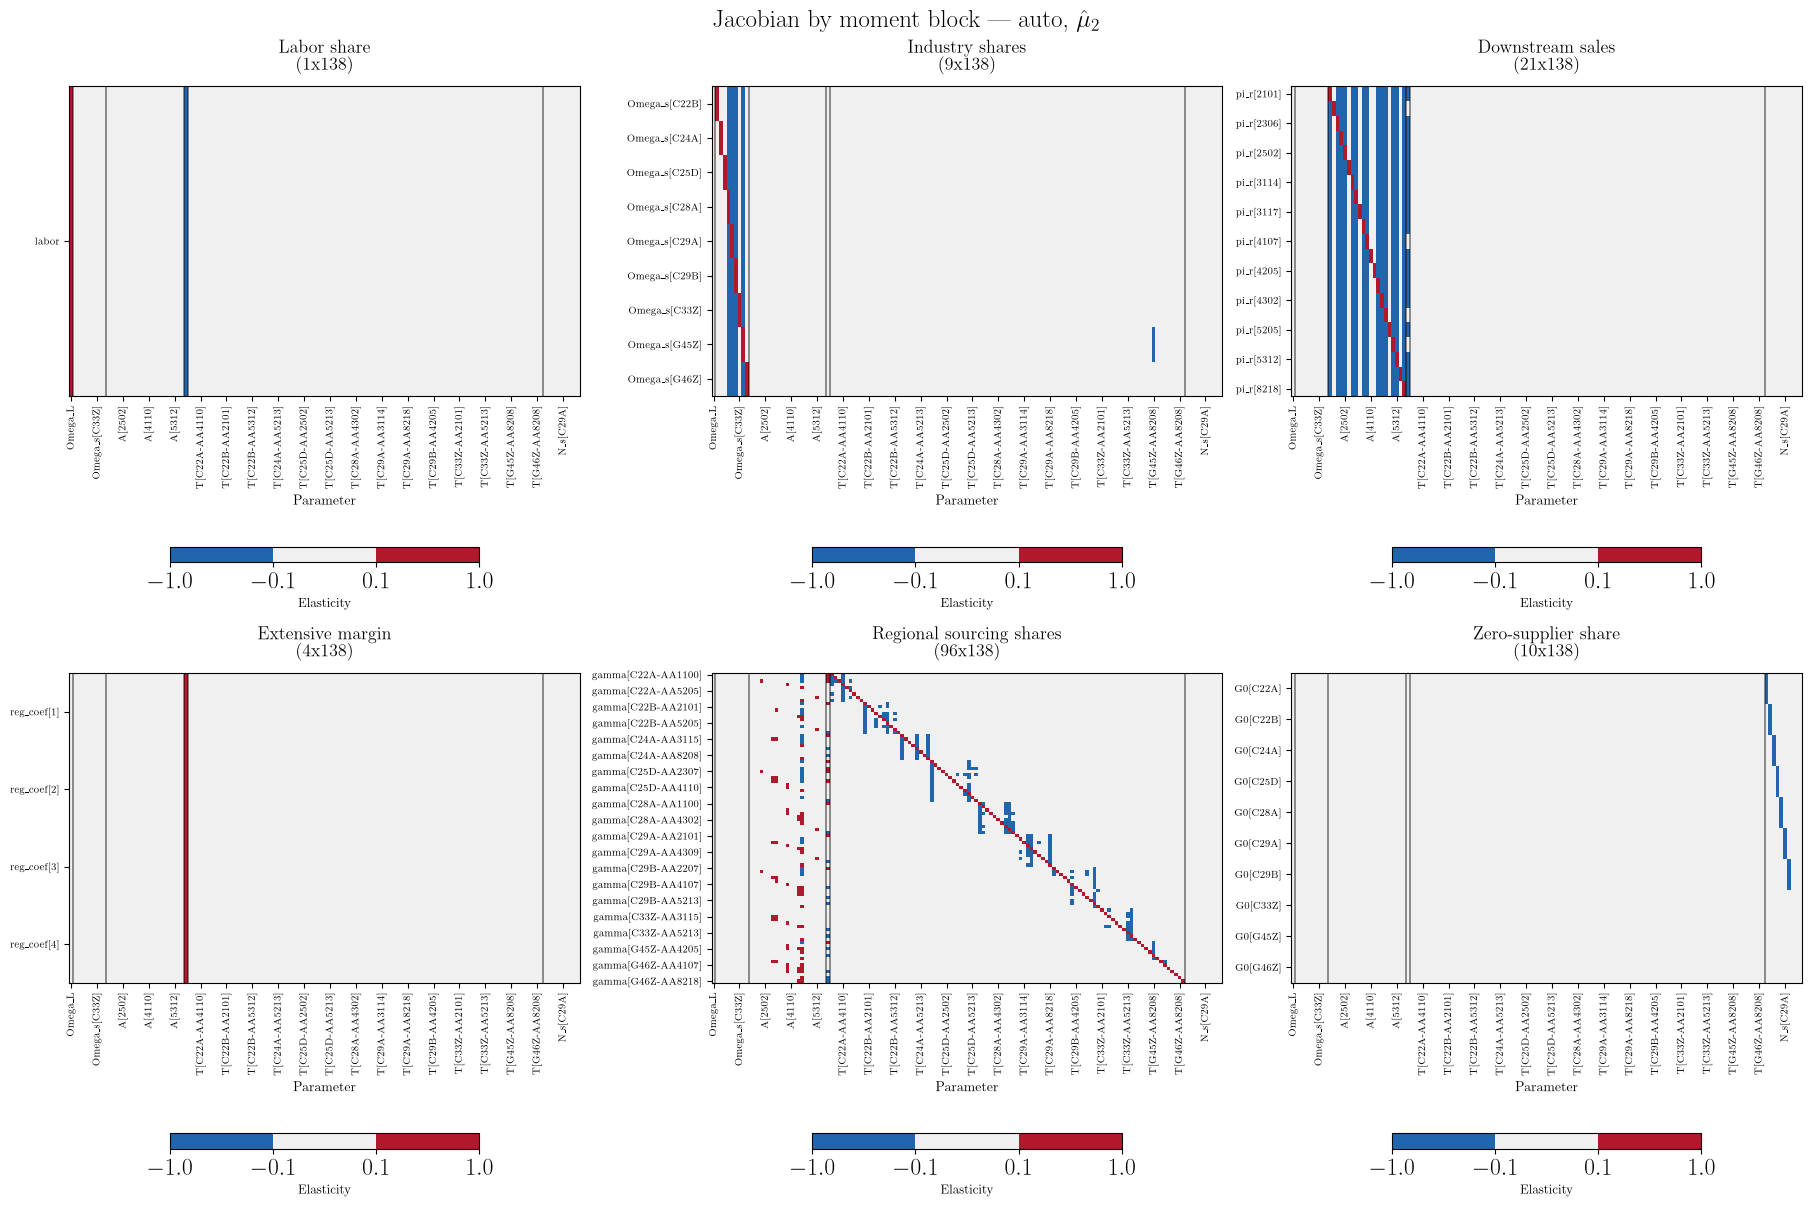

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.884438        0.010596     0.006953   0.234922   
Industry shares           0.000229        0.194313     0.002365   0.009919   
Downstream sales          0.028300        0.010204     0.625268   0.170805   
Extensive margin          0.000000        0.000000     0.000000   0.954735   
Regional sourcing shares  0.001302        0.000636     0.023017   0.071584   
Zero-supplier share       0.000000        0.000000     0.000000   0.039915   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.001625      0.000000  0.884438   
Industry shares                       0.005698      0.000000  0.000678   
Downstream sales                      0.002662      0.000000  0.057063   
Extensive margin                      0.010118      0.000000  0.000000   
Regional sourcing shares              0.016742      0.000000  0.003531   
Zero-supplier share                   0.000247      0.015045  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.031046     0.027231   0.234922   
Industry shares                 0.969399     0.029110   0.035103   
Downstream sales                0.072148     8.982848   0.345315   
Extensive margin                0.000000     0.000000   0.985154   
Regional sourcing shares        0.004776     0.567888   0.218268   
Zero-supplier share             0.000000     0.000000   0.071405   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.011803      0.000000       1.000000   
Industry shares                       0.173228      0.000000       0.888889   
Downstream sales                      0.074231      0.000000       1.000000   
Extensive margin                      0.060086      0.000000       1.000000   
Regional sourcing shares              1.309243      0.000000       0.583333   
Zero-supplier share                   0.031319      0.262217       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.888889     0.952381   1.000000   
Industry shares                 1.000000     0.804233   0.777778   
Downstream sales                0.809524     1.000000   0.952381   
Extensive margin                1.000000     1.000000   0.500000   
Regional sourcing shares        0.590278     0.585317   0.020833   
Zero-supplier share             1.000000     1.000000   0.900000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           1.000000           1.0  
Industry shares                       1.000000           1.0  
Downstream sales                      0.601687           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.501519           1.0  
Zero-supplier share                   0.900000           1.0

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  10 variety-count columns in the Jacobian


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


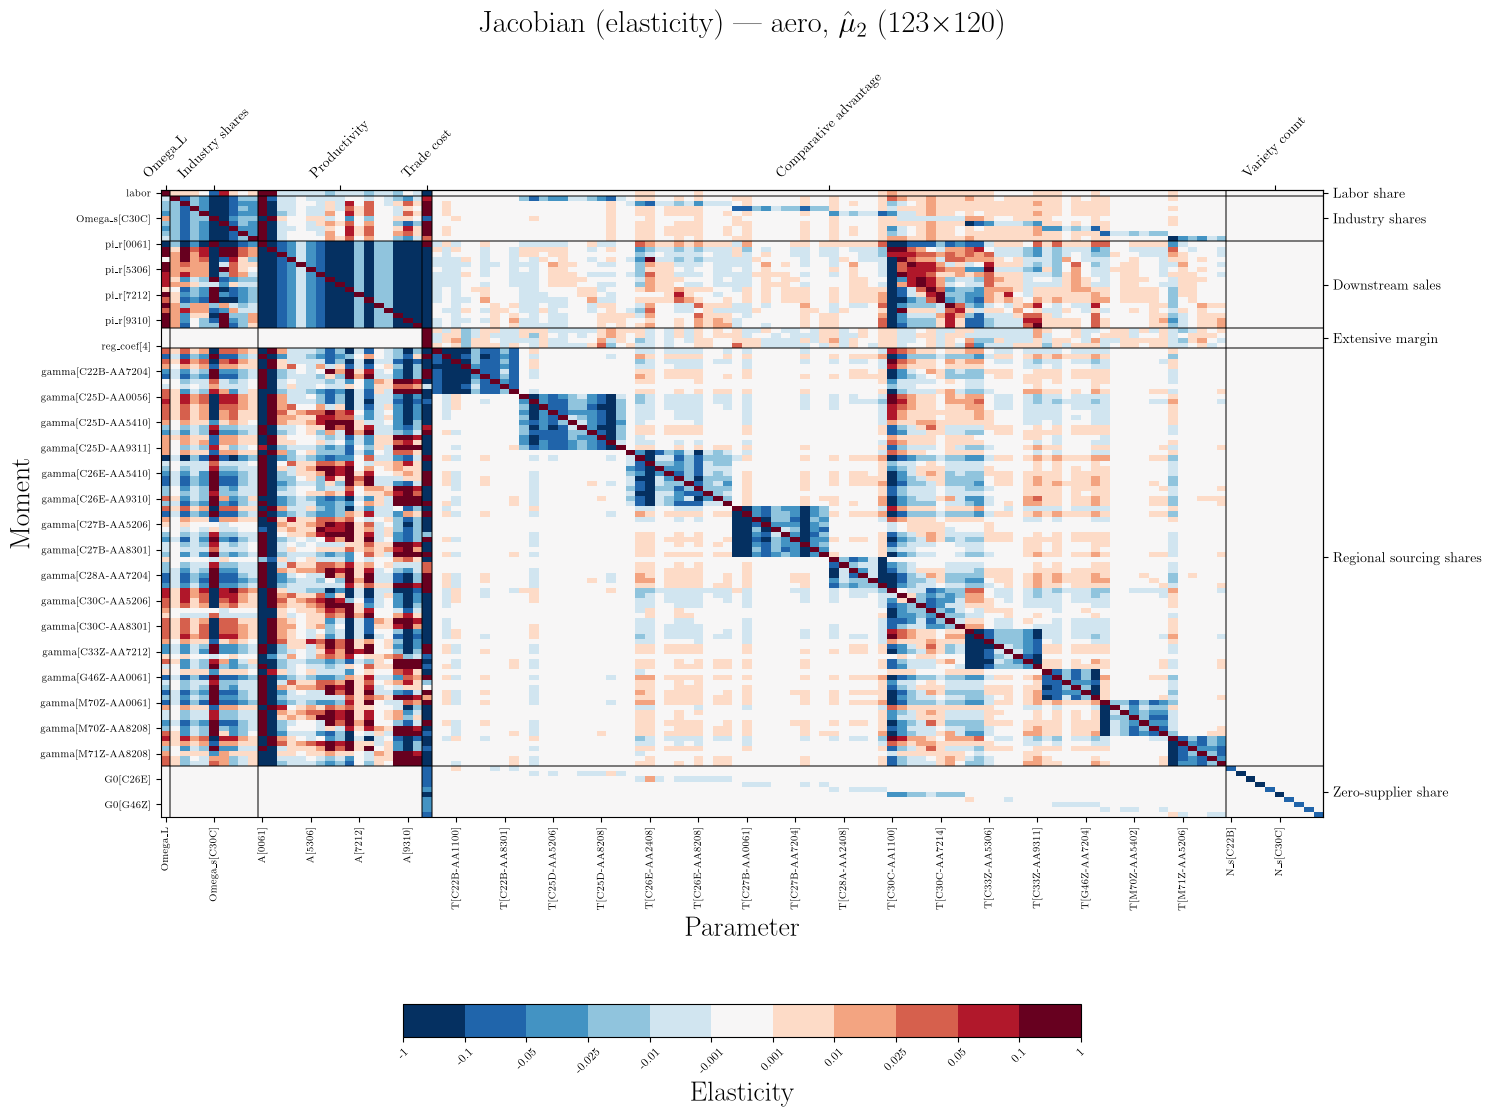

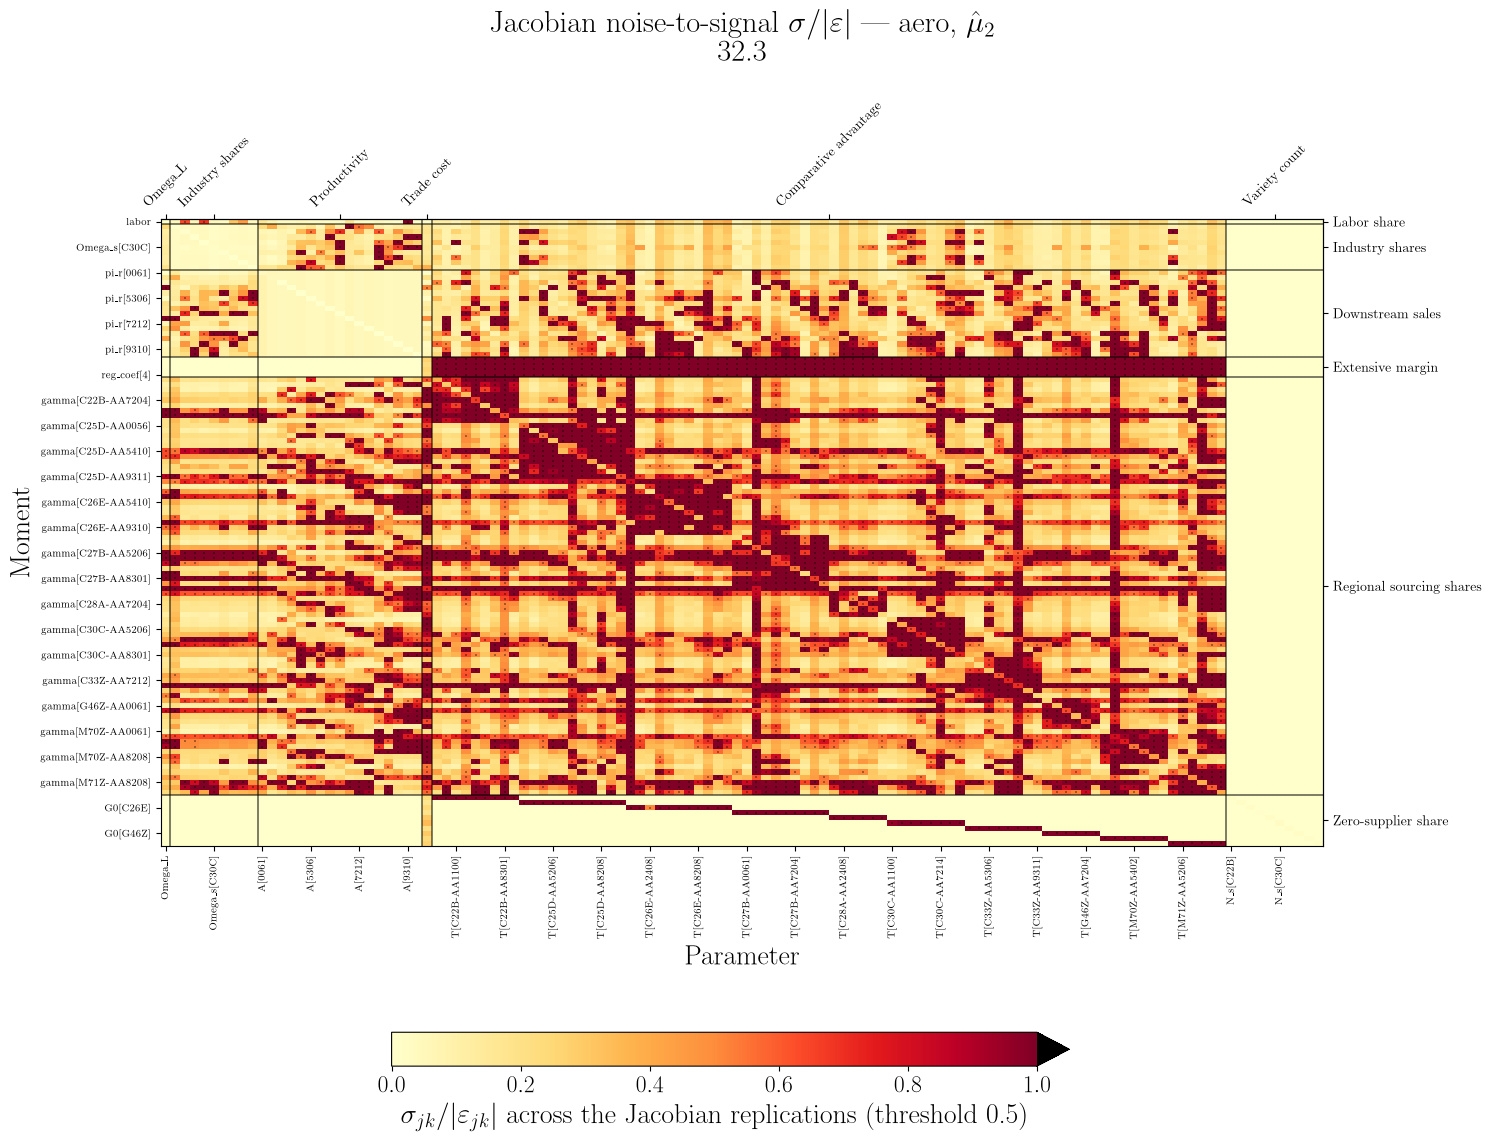

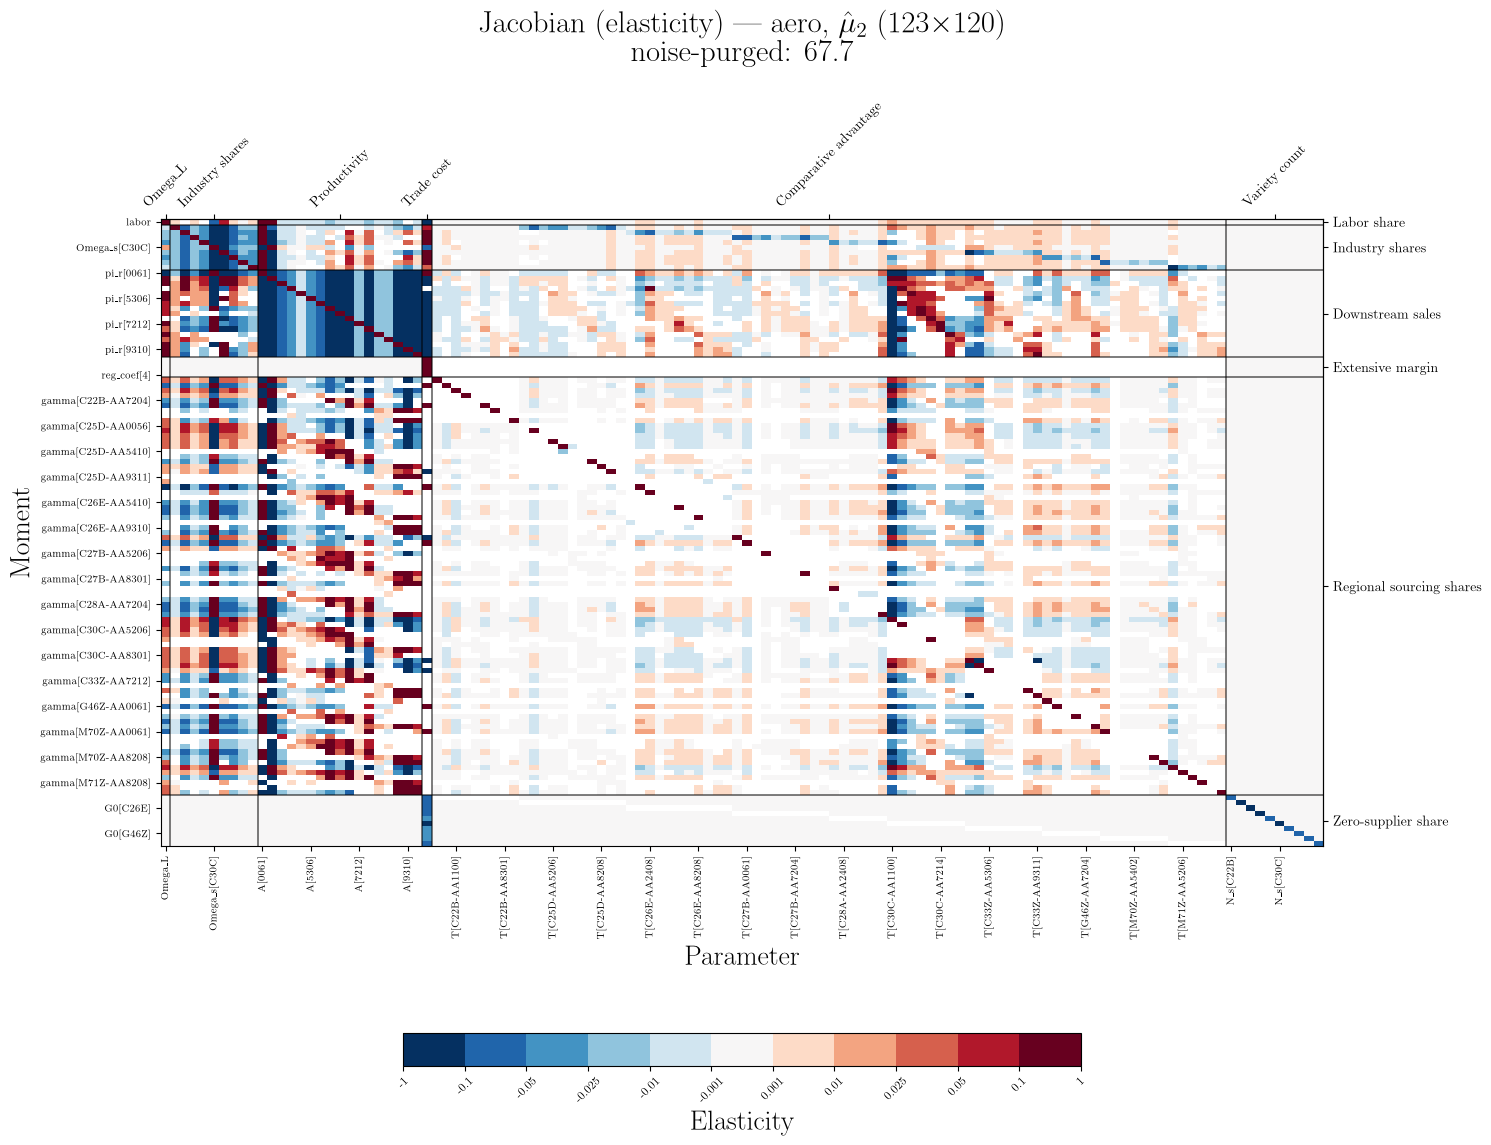

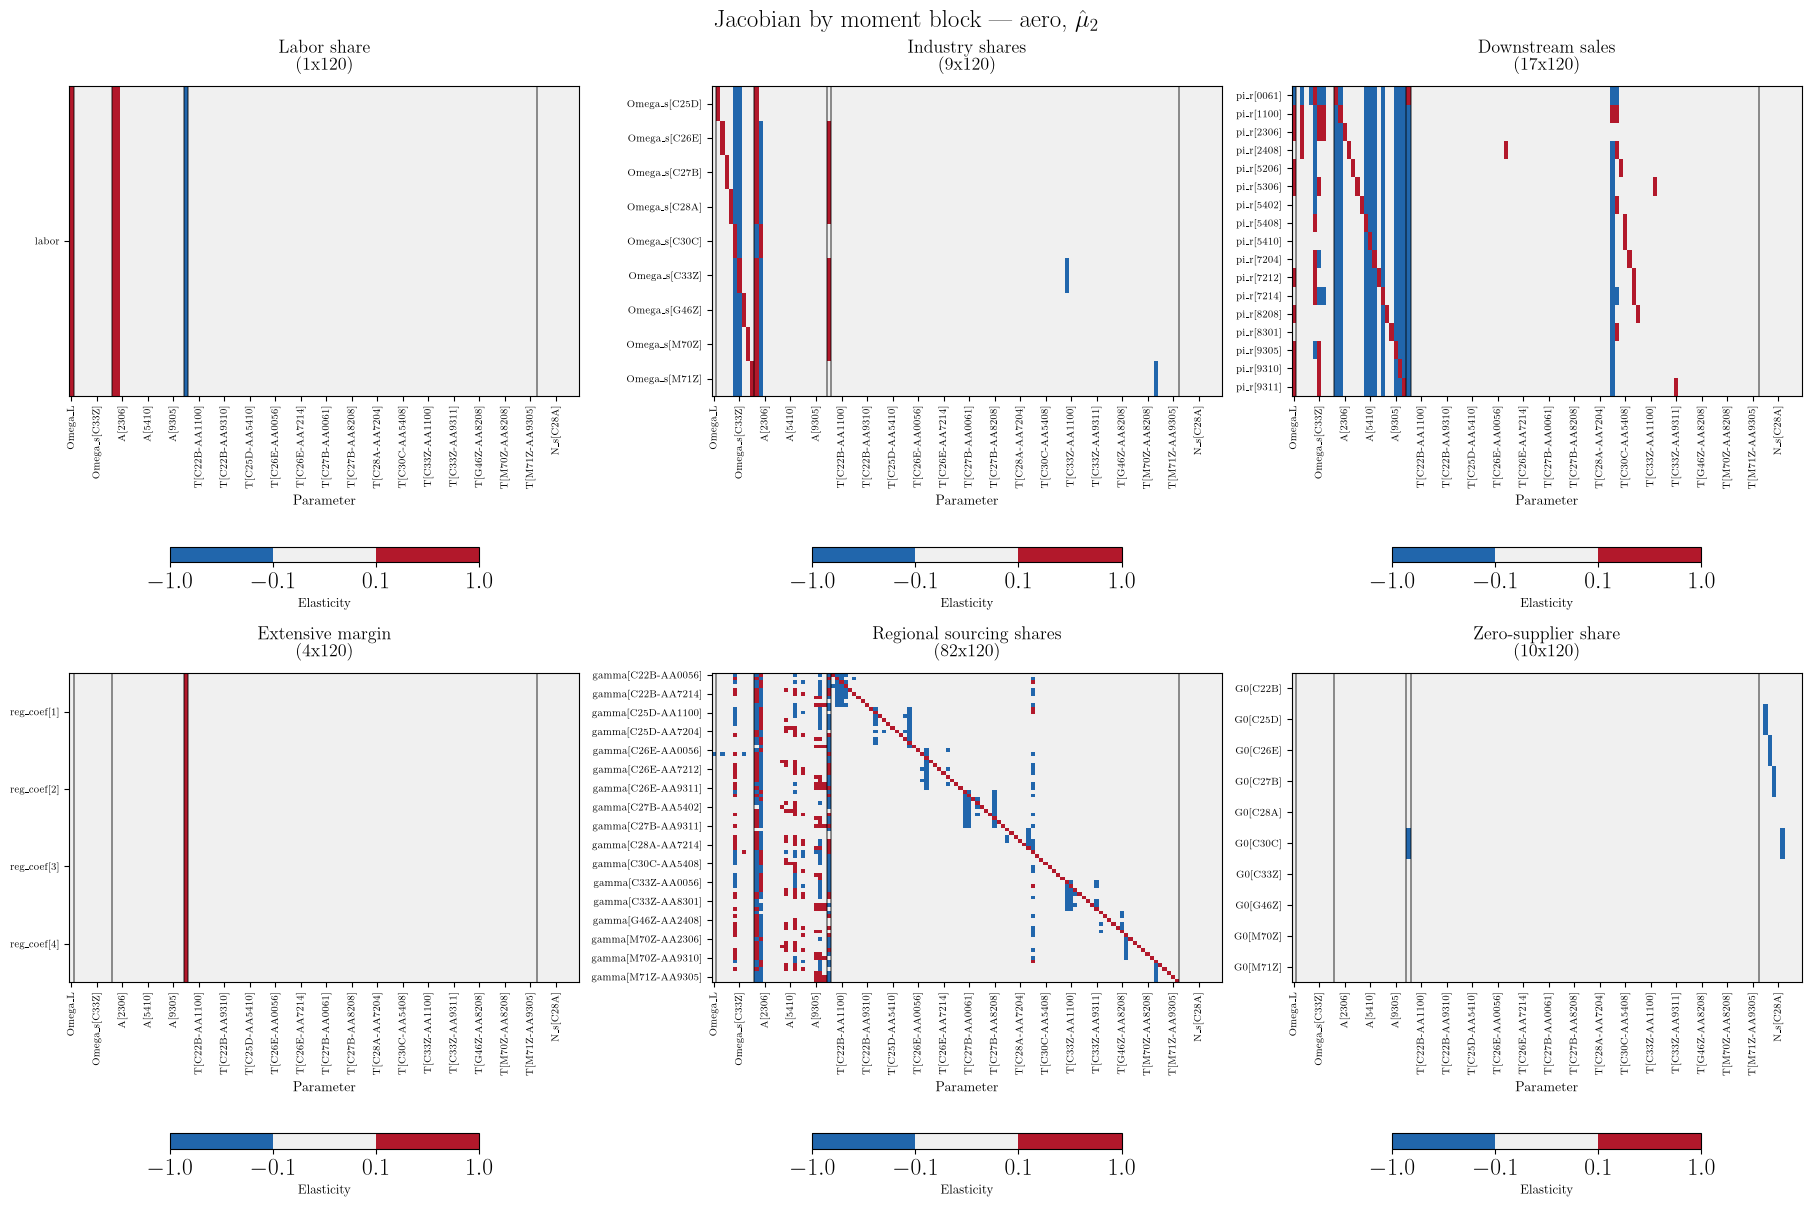

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.956238        0.020153     0.041391   0.569855   
Industry shares           0.017529        0.192971     0.088644   0.143604   
Downstream sales          0.155750        0.068892     1.740359   1.411385   
Extensive margin          0.000000        0.000000     0.000000   1.006542   
Regional sourcing shares  0.031423        0.033269     0.226080   0.308232   
Zero-supplier share       0.000000        0.000000     0.000000   0.067914   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.001332      0.000000  0.956238   
Industry shares                       0.004475      0.000000  0.030297   
Downstream sales                      0.012165      0.000000  0.450386   
Extensive margin                      0.004184      0.000000  0.000000   
Regional sourcing shares              0.020486      0.000000  0.108683   
Zero-supplier share                   0.000352      0.011148  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.092805     0.406214   0.569855   
Industry shares                 0.980547     1.235046   0.262206   
Downstream sales                0.971018    16.059114   3.800084   
Extensive margin                0.000000     0.000000   1.010483   
Regional sourcing shares        0.437059     4.455369   1.289717   
Zero-supplier share             0.000000     0.000000   0.197590   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.023398      0.000000       1.000000   
Industry shares                       0.162362      0.000000       1.000000   
Downstream sales                      0.422385      0.000000       0.882353   
Extensive margin                      0.032523      0.000000       1.000000   
Regional sourcing shares              1.189538      0.000000       0.719512   
Zero-supplier share                   0.030136      0.277237       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.777778     0.941176   1.000000   
Industry shares                 1.000000     0.797386   1.000000   
Downstream sales                0.803922     1.000000   0.941176   
Extensive margin                1.000000     1.000000   1.000000   
Regional sourcing shares        0.726287     0.618364   0.121951   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           1.000000           1.0  
Industry shares                       0.943089           1.0  
Downstream sales                      0.678623           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.557258           1.0  
Zero-supplier share                   0.900000           1.0

In [45]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"{data['n_N_cols']} variety-count columns in the Jacobian")

    # the triptych: as is, the noise-to-signal map, and the purged matrix
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))


## Variance-covariance of the moments


Three matrices, all written by Step 2:

* $\Sigma_{data}$ — the bootstrap covariance of the **empirical** moments: how precisely
  the targets are measured;
* $\Sigma_{sim}$ — the covariance across $K$ re-simulations at $\hat\theta_1$: how much
  of the moment vector is Monte-Carlo noise from the simulator;
* $\Omega = \Sigma_{data} + \Sigma_{sim}$ — what the estimator actually weighted with,
  $W = \Omega^{-1}$.

Two views of each. The **covariance** panels are on a common diverging scale, so the
relative magnitude of the three is visible — which is the point, since
$\mathrm{tr}(\Sigma_{sim})/\mathrm{tr}(\Sigma_{data})$ is the share of the weighting that
is simulation rather than data, and the dial for it is `--n_rho_inf`. The **correlation**
panels rescale each matrix by its own diagonal, which removes that magnitude and leaves
the dependence structure: whether the sampling error of the sourcing shares is correlated
across areas, whether the simulation noise is (it is, through the shared draws), and
whether $\Omega$ inherits its correlation from the data or from the simulator.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


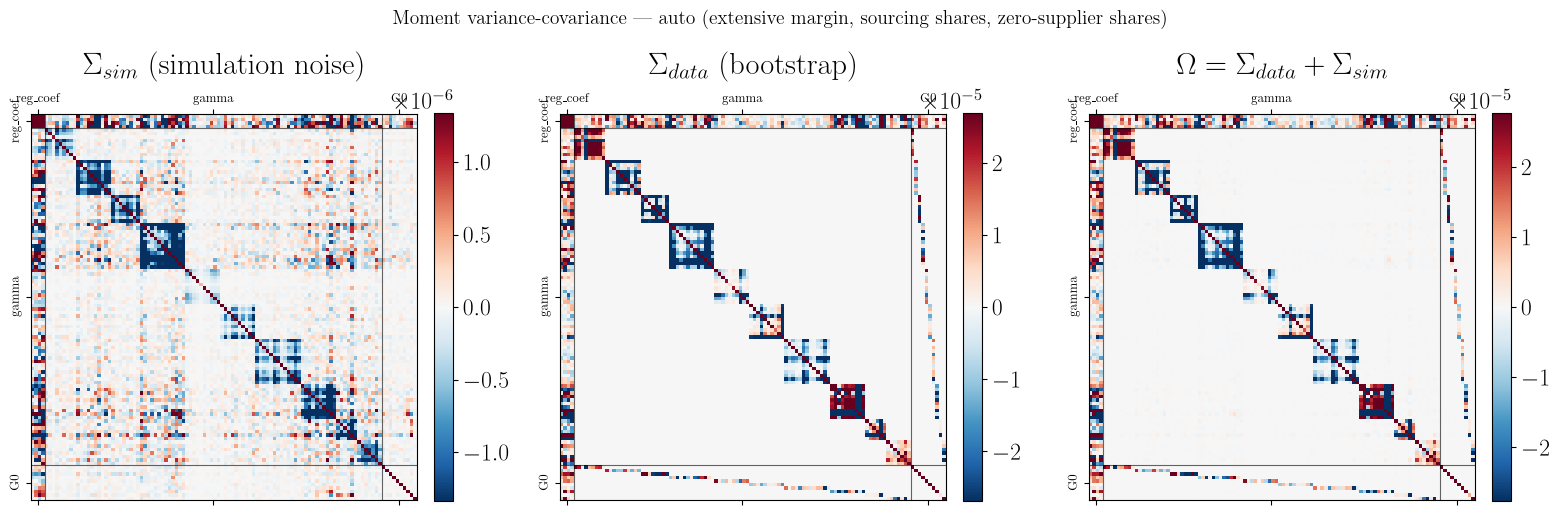

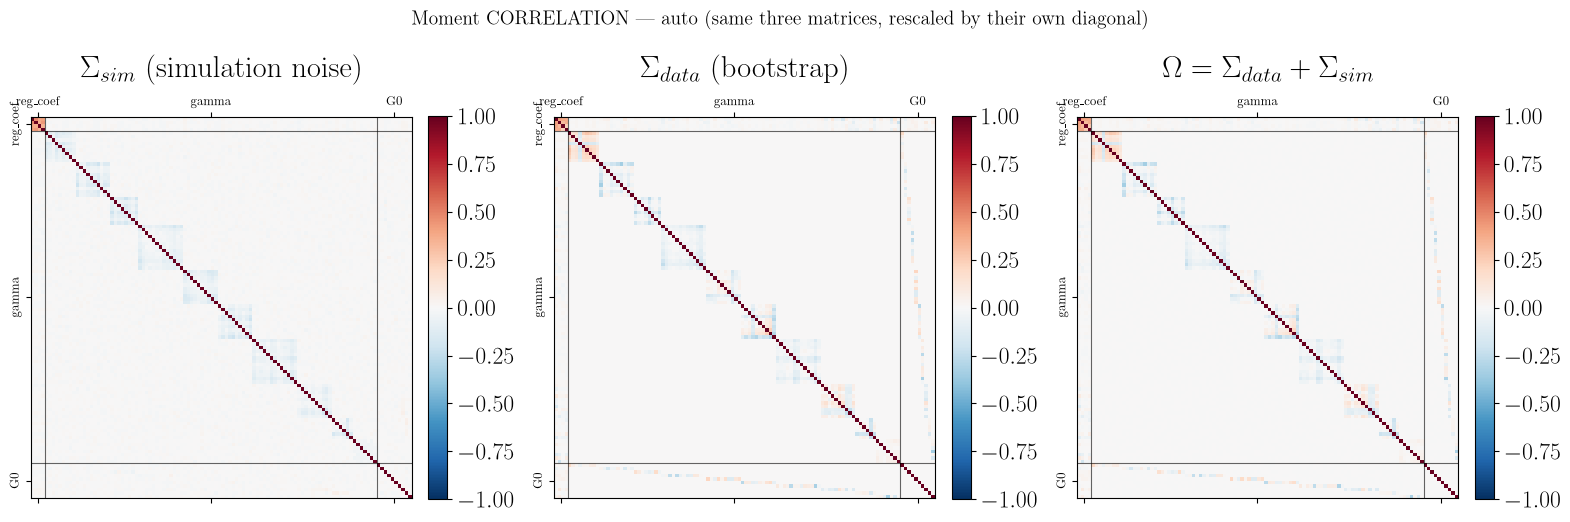

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.104737,3.682713e-06,0.016072,4364.240277,0.008364,NaN
Sigma_sim,0.004589,4.042591e-07,0.001014,2507.366363,0.012739,0.043811
Omega,0.109326,5.585248e-06,0.016376,2932.030613,0.008296,NaN


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


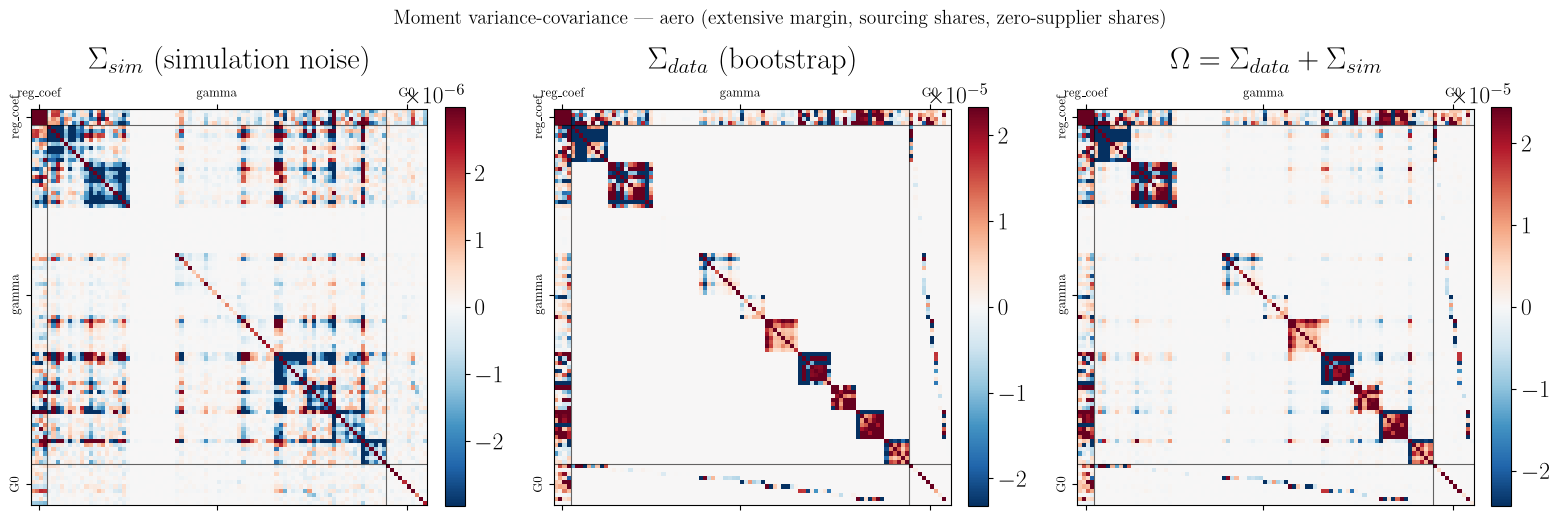

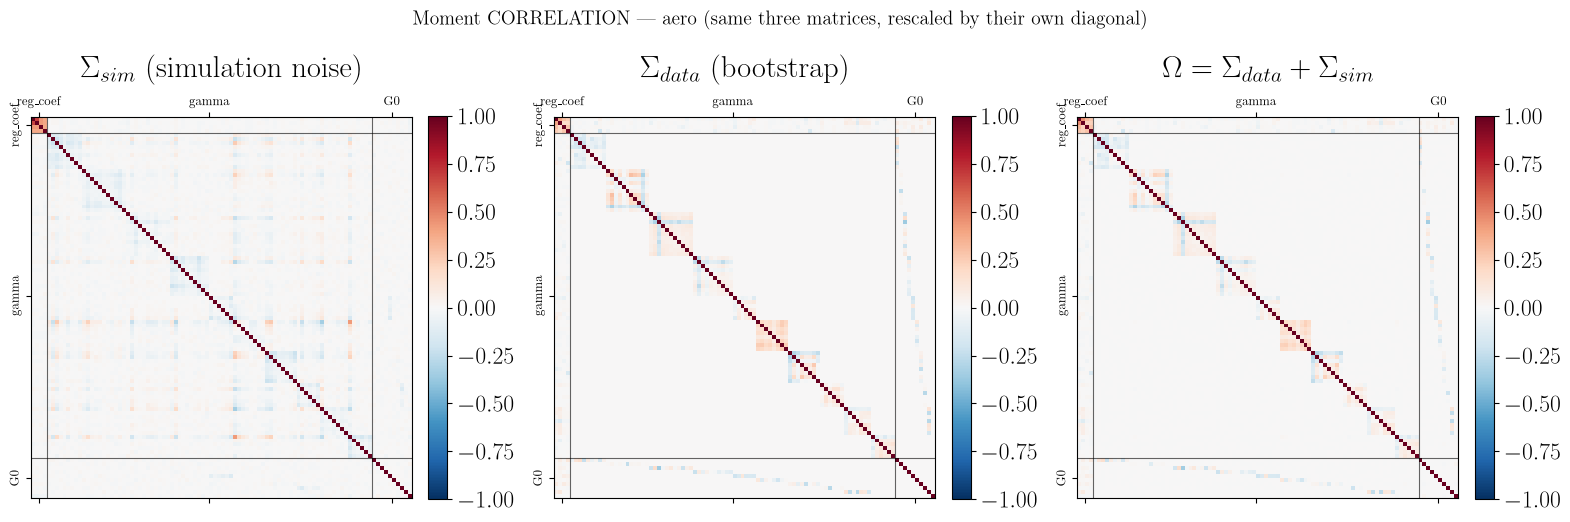

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.105054,1.109410e-31,0.018817,1.696163e+29,0.009591,NaN
Sigma_sim,0.004937,2.871127e-10,0.001323,4.608139e+06,0.019351,0.046992
Omega,0.109991,4.243904e-09,0.019033,4.484753e+06,0.009530,NaN


In [46]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(
        data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))


## Identification / sensitivity

A sensitivity analysis fixes every parameter, moves one of them above and below its
estimate, and checks that the moments respond smoothly and in the direction the design
predicts. The elasticity Jacobian *is* that experiment, linearised at the estimate:
$\varepsilon_{jk} = \partial \log m_j / \partial \log \theta_k$ is the local slope of
moment $j$ against parameter $k$. With ten sectors, the attraction areas, the $T$ block
and the variety counts there are far too many parameters to draw a curve each, so the
matrix is drawn instead and everything too small — or too noisy — is blanked out.

Two thresholds, and they answer different questions:

* $|\varepsilon| \geq$ `IDENT_THRESHOLD` (0.01): a 1% move in the parameter shifts the
  moment by at least 0.01%. **Is there a channel?**
* $\sigma/|\varepsilon| <$ `NOISE_MAX` (0.5): the elasticity is estimated precisely
  enough relative to its own size. **Can we see it?** An entry that fails this is not
  evidence of a weak channel; it is evidence of nothing at all, and the summary counts it
  separately rather than pooling it with the structural zeros.

What the figures are meant to show: the three channels are close to orthogonal *by
construction*. $\alpha$ is read from a **within**-area distance gradient that comparative
advantage cannot touch, since comparative advantage is constant within an area; $T_{as}$
is read from **across**-area value shares; $N_s$ is read from the **level** of the
empty-region share, which the sector $\times$ nearest-downstream fixed effect strips out
of the $\alpha$ regression. So the expected picture is near-block-diagonal on the
(Trade cost, Comparative advantage, Variety count) $\times$ (Extensive margin, Regional
sourcing shares, Zero-supplier share) corner — and in the $N_s$ columns *exact* zeros
rather than merely small numbers.


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


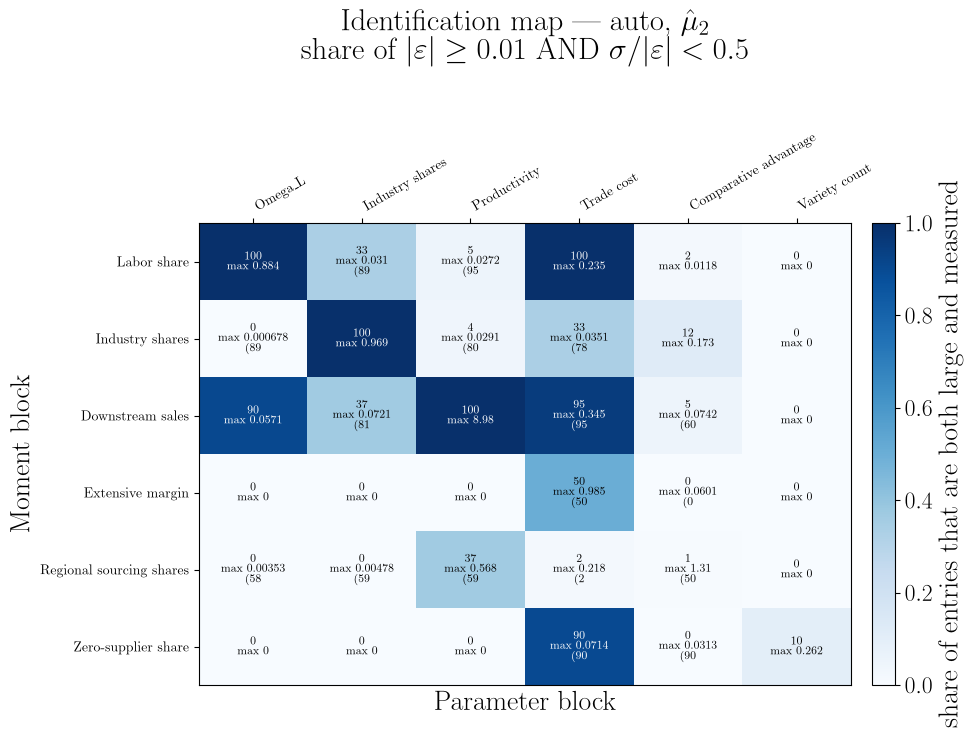

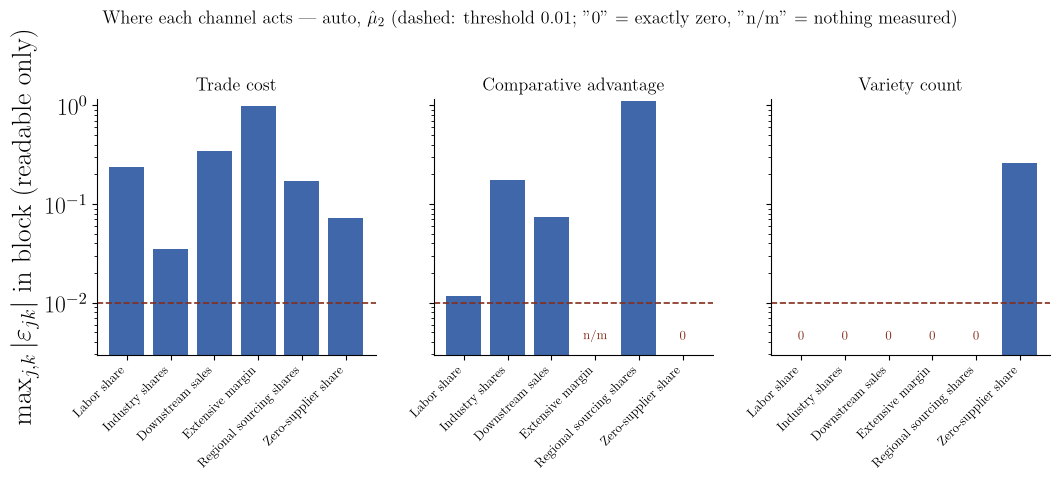

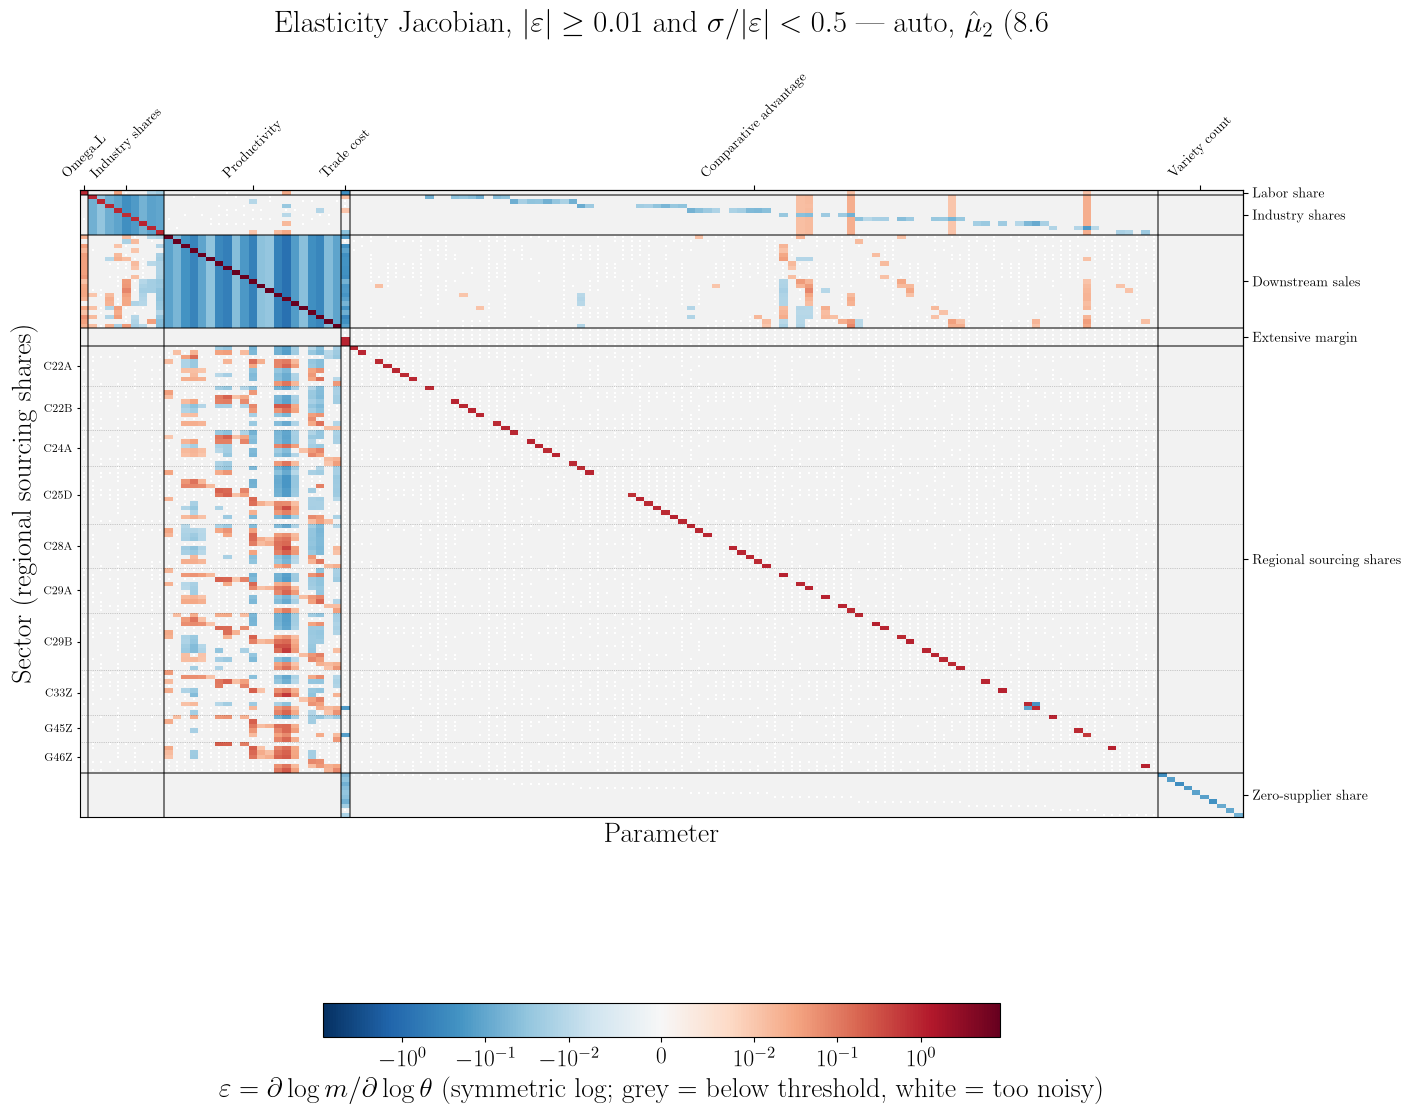

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.333333     0.047619   1.000000   
Industry shares             0.000000        1.000000     0.042328   0.333333   
Downstream sales            0.904762        0.365079     1.000000   0.952381   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.000000        0.000000     0.459821   0.927083   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.020833           0.0       1.000000   
Industry shares                       0.118056           0.0       0.888889   
Downstream sales                      0.048115           0.0       1.000000   
Extensive margin                      0.382812           0.0       1.000000   
Regional sourcing shares              0.100260           0.0       0.583333   
Zero-supplier share                   0.001042           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.888889     0.952381   1.000000  ...   
Industry shares                 1.000000     0.804233   0.777778  ...   
Downstream sales                0.809524     1.000000   0.952381  ...   
Extensive margin                1.000000     1.000000   0.500000  ...   
Regional sourcing shares        0.590278     0.585317   0.020833  ...   
Zero-supplier share             1.000000     1.000000   0.900000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.006953   0.234922              0.001625   
Industry shares              0.002365   0.009919              0.005698   
Downstream sales             0.625268   0.170805              0.002662   
Extensive margin             0.000000   0.954735              0.010118   
Regional sourcing shares     0.023017   0.071584              0.016742   
Zero-supplier share          0.000000   0.039915              0.000247   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.015045              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


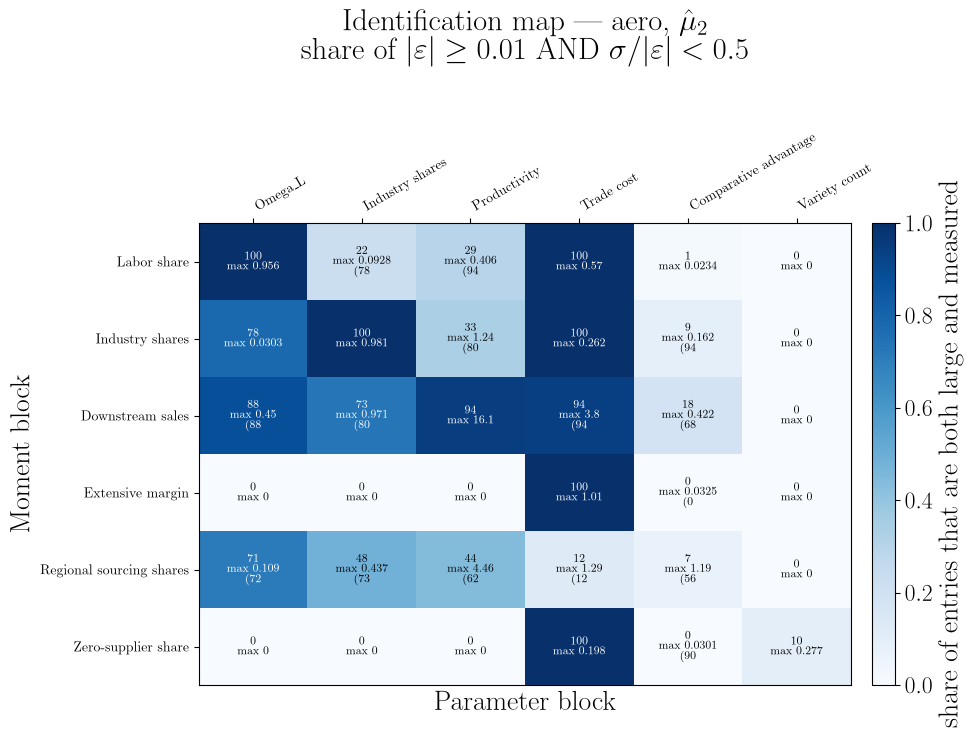

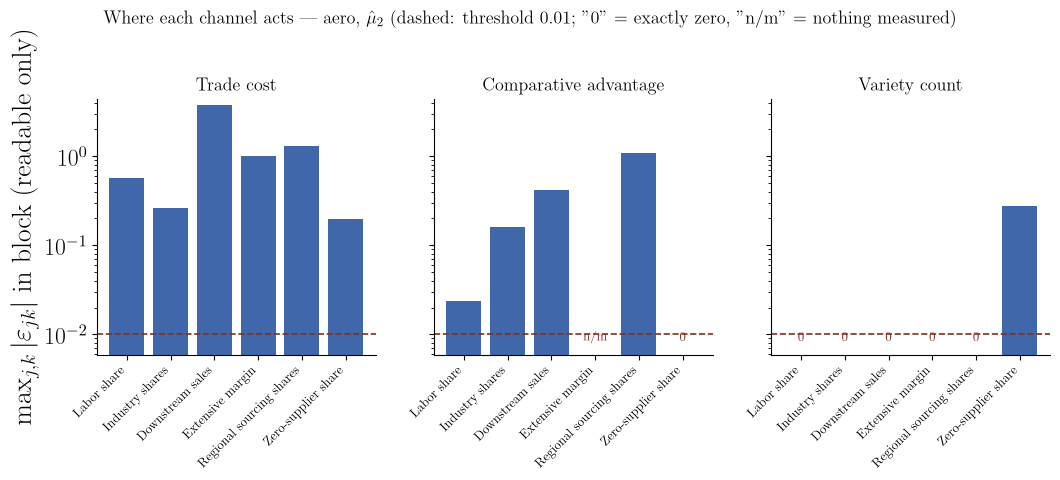

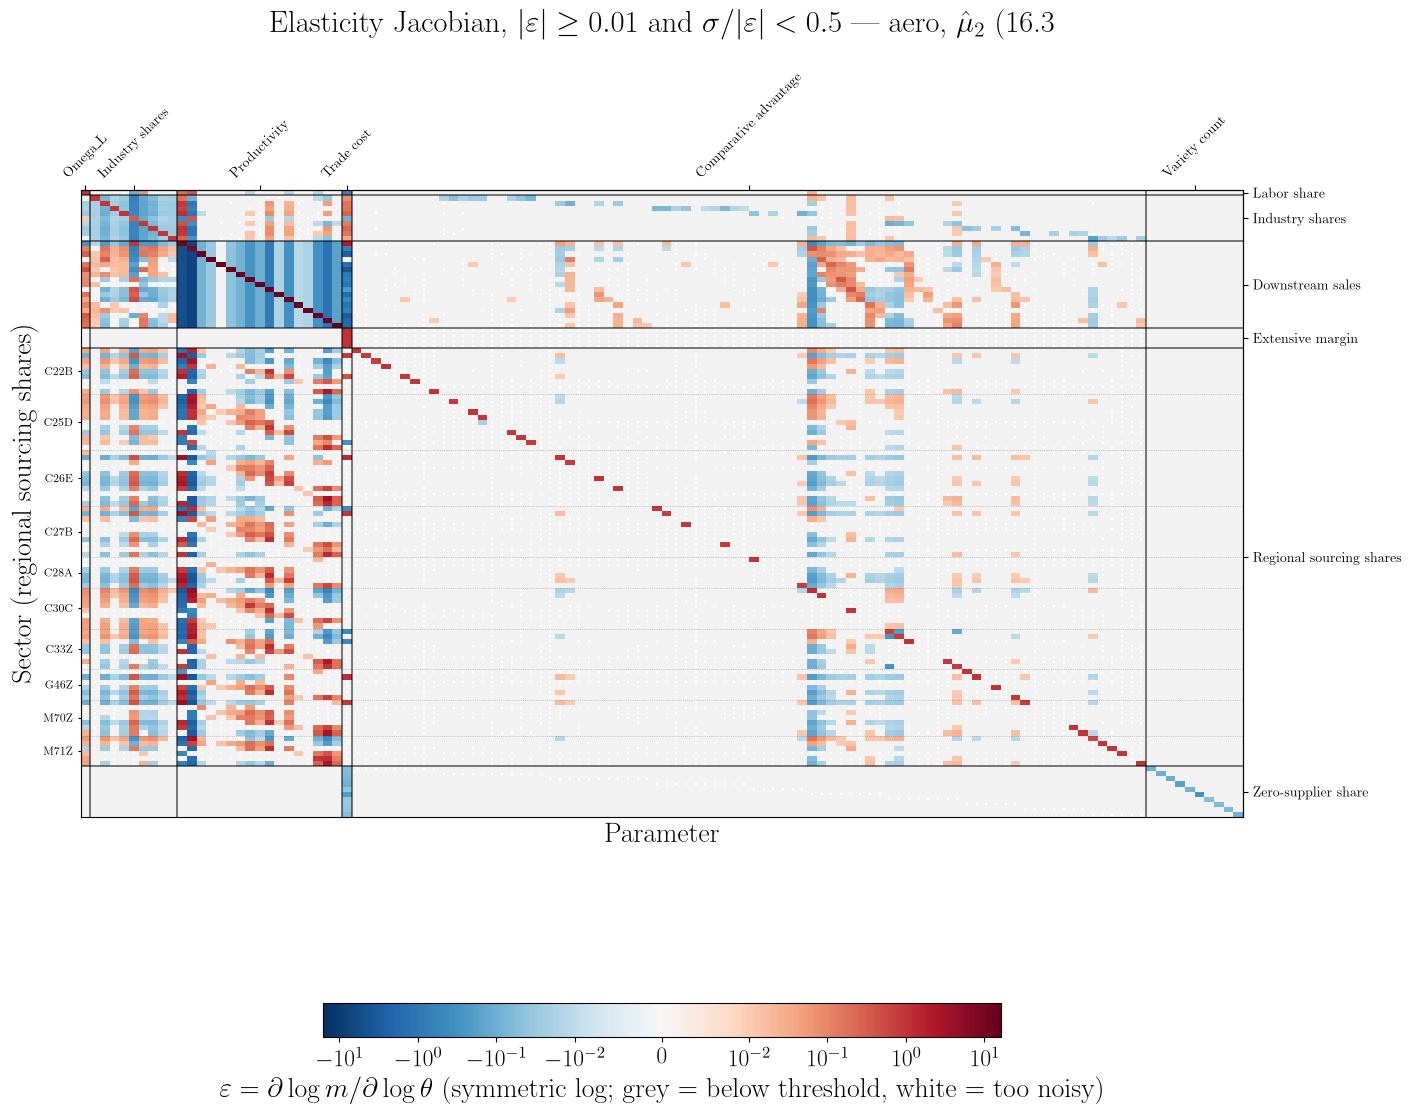

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.222222     0.294118    1.00000   
Industry shares             0.777778        1.000000     0.333333    1.00000   
Downstream sales            0.882353        0.816993     0.944637    1.00000   
Extensive margin            0.000000        0.000000     0.000000    1.00000   
Regional sourcing shares    0.817073        0.548780     0.589670    0.97561   
Zero-supplier share         0.000000        0.000000     0.000000    1.00000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.012195           0.0       1.000000   
Industry shares                       0.089431           0.0       1.000000   
Downstream sales                      0.195839           0.0       0.882353   
Extensive margin                      0.079268           0.0       1.000000   
Regional sourcing shares              0.157644           0.0       0.719512   
Zero-supplier share                   0.009756           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.777778     0.941176   1.000000  ...   
Industry shares                 1.000000     0.797386   1.000000  ...   
Downstream sales                0.803922     1.000000   0.941176  ...   
Extensive margin                1.000000     1.000000   1.000000  ...   
Regional sourcing shares        0.726287     0.618364   0.121951  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.041391   0.569855              0.001332   
Industry shares              0.088644   0.143604              0.004475   
Downstream sales             1.740359   1.411385              0.012165   
Extensive margin             0.000000   1.006542              0.004184   
Regional sourcing shares     0.226080   0.308232              0.020486   
Zero-supplier share          0.000000   0.067914              0.000352   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.011148              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

In [47]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))
